# How long do new SKUs stay on the shelf? Survival analysis of new-product listings in FMCG

**Author:** Fordrane Albert Okumu · **Tools:** Python (lifelines, pandas, NumPy, matplotlib)
**Companion:** the same Kaplan-Meier, log-rank, Cox and Weibull models rebuilt in R with the `survival` package live in [`R/fmcg_survival.R`](../R/fmcg_survival.R), with a coefficient-by-coefficient cross-check.

---

## 0. The business question

Every year an FMCG dairy business launches new SKUs: a Greek-style yoghurt, a halloumi, a new ice-cream flavour. The sales team works hard to get each one **listed** (ranged) in as many outlets as possible. But a listing is not a sale. Many new SKUs are quietly **delisted** a few months later: the supermarket drops them at the next range review, or the duka owner simply stops re-ordering.

Launch budgets (trade promotions, POS material, merchandiser time) are spent at launch, so the questions that matter are:

1. **How long does a new listing typically survive?** What share is still on the shelf after one quarter, six months, a year?
2. **What drives delisting?** Channel, category, price, margin, distance, shelf life, and above all, how well the product sells in its first weeks.
3. **Does launch support work, and for how long?** Is trade-promotion funding buying a lasting listing, or only a few extra weeks?
4. **Where should the next launch budget go?** Which outlets and which conditions give the most listing-weeks per shilling?

> In my day-to-day work in FMCG dairy, new-product listings are reviewed as "listed / not listed" snapshots. This project shows why a **time-to-event** view gives better answers, using methods I first learned in biostatistics, where the same mathematics is used to study how long patients survive or stay in treatment.

### Why survival analysis, and not a simple "% delisted" or a logistic churn model?

Look at how the data arrives:

* SKUs launch at **different dates** (March 2024 to February 2026), and each one rolls out to outlets over several weeks. This is **staggered entry**: every listing has its own "day 0".
* The study stops on **30 June 2026**. A listing that started in May 2024 has been watched for two years; one that started in March 2026 for only a few weeks. For most of the recent listings we **do not yet know** when (or whether) they will be delisted. This is **right-censoring**.
* Some outlets **close down**. Their listings end, but not because the product failed, so we must not count them as delistings. They are also censored.

A naive "% delisted" compares old listings (long exposure) with new ones (short exposure), so recent launches always look better. A **logistic churn model** has the same problem: it needs a fixed window ("delisted within 26 weeks?") and must either throw away every listing observed for less than 26 weeks or wrongly treat them as "not delisted". **Survival analysis** uses every listing for exactly as long as it was observed, and answers *when*, not just *whether*.

### Key definitions

| Term | Meaning here |
|---|---|
| **Time origin (t = 0)** | The listing date: the day the SKU first goes live in that outlet |
| **Event** | The outlet **delists** the SKU (stops stocking / drops it from its range) |
| **Survival time T** | Weeks from listing to delisting |
| **Right-censoring** | We only know T is *greater than* the observed time: the SKU was still listed at the cut-off (**administrative censoring**) or the outlet closed (**censoring by a competing exit**) |
| **Staggered entry** | Listings start on different calendar dates, so the same cut-off gives each listing a different follow-up time |
| **Survival function S(t)** | P(T > t): the probability that a listing is still on the shelf *t* weeks after listing |
| **Hazard h(t)** | The instantaneous delisting rate at week *t* among listings that have survived to *t*: roughly "the % of surviving listings delisted in week *t*" |
| **Cumulative hazard H(t)** | The hazard accumulated up to *t*; S(t) = exp(−H(t)) |
| **Hazard ratio (HR)** | How many times higher (HR > 1) or lower (HR < 1) the delisting rate is for one group vs another, at any given time |

The key assumption behind all the methods below is **non-informative censoring**: a listing censored at week *t* has the same future delisting risk as a similar listing still being observed. Administrative censoring satisfies this by design. Outlet closure is more debatable (a struggling outlet may stop ordering *before* it closes), and we check it in section 2.

### The data

The data is **synthetic**, generated by [`data/generate_data.py`](../data/generate_data.py) to behave like real listing data: about 6,900 outlet × SKU listings for 15 SKU launches across 2,200 outlets. Hidden effects (including an unobserved "appeal" for each SKU) drive the delisting hazard, and only the observable columns are exported. **No real company, outlet or sales data is used.**

| Column | Meaning |
|---|---|
| `listing_date`, `exit_date`, `weeks_listed` | Entry, exit and time on shelf |
| `delisted` | 1 = delisted (event), 0 = censored |
| `status` | Delisted / Censored: still listed at cut-off / Censored: outlet closed |
| `channel`, `region`, `distance_km`, `has_merchandiser` | Outlet attributes |
| `category`, `shelf_life_days` | SKU attributes |
| `trade_promo`, `pos_material` | Launch support: promo funding during the first 16 weeks; POS material / planogram placement |
| `price_index` | Shelf price vs category average in that outlet (100 = parity) |
| `retailer_margin_pct` | Outlet's margin on the SKU |
| `sellthrough_4wk_pct` | % of the opening stock sold in the first 4 weeks |

Listing contracts guarantee a **4-week minimum listing period**, so no delisting can happen before week 4 and the 4-week sell-through is known for every listing before it can be delisted. This matters: a covariate measured *after* time zero can create **immortal-time bias** if events can happen before it is measured. Here the contract rules that out.

## 1. Setup

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import (KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter, CoxTimeVaryingFitter,
                       WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter,
                       WeibullFitter, LogNormalFitter, LogLogisticFitter)
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test, proportional_hazard_test
from lifelines.utils import restricted_mean_survival_time, concordance_index, median_survival_times
from lifelines.plotting import add_at_risk_counts

ROOT = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
OUT = ROOT / "outputs" / "python"; OUT.mkdir(parents=True, exist_ok=True)
TEAL, AMBER, GREY, RED = "#0f766e", "#b45309", "#94a3b8", "#b91c1c"
NAVY, PURPLE = "#1e3a8a", "#7c3aed"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
pd.set_option("display.width", 170, "display.max_columns", 30)
CUTOFF, PROMO_WEEKS, TAU = pd.Timestamp("2026-06-30"), 16, 52   # study cut-off, promo window, RMST horizon

## 2. Load the data and check it, especially the censoring

Before any modelling, survival data needs checks that ordinary tables don't:

* **Logical consistency:** exit date after listing date, durations match the dates, nothing after the cut-off, no delisting inside the 4-week contract period.
* **Event and censoring mix:** how many listings were delisted, still listed, or lost to outlet closure?
* **Follow-up:** how long were listings observed? With staggered entry this varies a lot by launch.

In [2]:
df = pd.read_csv(ROOT / "data" / "sku_listings.csv", parse_dates=["launch_date", "listing_date", "exit_date"])
print(f"{len(df):,} listings | {df.outlet_id.nunique():,} outlets | {df.sku_id.nunique()} SKU launches | "
      f"listed {df.listing_date.min():%d %b %Y} – {df.listing_date.max():%d %b %Y} | cut-off {CUTOFF:%d %b %Y}")
checks = pd.Series({
    "missing values": int(df.isna().sum().sum()),
    "duplicate listing_id": int(df.listing_id.duplicated().sum()),
    "duplicate outlet x SKU pairs": int(df.duplicated(["outlet_id", "sku_id"]).sum()),
    "exit before listing": int((df.exit_date < df.listing_date).sum()),
    "exit after cut-off": int((df.exit_date > CUTOFF).sum()),
    "days_listed != exit - listing": int(((df.exit_date - df.listing_date).dt.days != df.days_listed).sum()),
    "delisted inside 4-week contract": int(((df.delisted == 1) & (df.weeks_listed < 4)).sum()),
}, name="count")
display(checks.to_frame())
status = df.status.value_counts().to_frame("listings").assign(share=lambda d: (d.listings / len(df)).round(3))
status

6,924 listings | 2,228 outlets | 15 SKU launches | listed 04 Mar 2024 – 18 May 2026 | cut-off 30 Jun 2026


,count
missing values,0
duplicate listing_id,0
duplicate outlet x SKU pairs,0
exit before listing,0
exit after cut-off,0
days_listed != exit - listing,0
delisted inside 4-week contract,0


,listings,share
status,,
Delisted,3620,0.523
Censored: still listed at cut-off,3109,0.449
Censored: outlet closed,195,0.028


**Interpretation:** every logical check passes. Of the 6,924 listings, **3,620 (52.3%) were delisted**, **3,109 (44.9%) were still on the shelf at the cut-off** and **195 (2.8%) were lost to outlet closure**. Nearly half the data is censored. Throwing those listings away, or counting them as "survived", would badly bias any answer.

In [3]:
# Follow-up time: the "reverse Kaplan-Meier" treats censoring as the event, so it measures how long
# listings WOULD have been observed if nobody had been delisted (the standard way to report follow-up).
rev = KaplanMeierFitter().fit(df.weeks_listed, 1 - df.delisted)
print(f"Median potential follow-up (reverse KM): {rev.median_survival_time_:.1f} weeks | "
      f"observed time on shelf ranges {df.weeks_listed.min():.1f}–{df.weeks_listed.max():.1f} weeks")

by_launch = (df.groupby(["sku_id", "sku_name", "category", "launch_date"])
               .agg(listings=("listing_id", "size"),
                    max_followup_wks=("weeks_listed", lambda s: ((CUTOFF - df.loc[s.index, "listing_date"]).dt.days / 7).max()),
                    crude_pct_delisted=("delisted", "mean"),
                    pct_outlet_closed=("status", lambda s: (s == "Censored: outlet closed").mean()))
               .reset_index().round(3))
by_launch.assign(launch_date=by_launch.launch_date.dt.strftime("%b %Y"))

Median potential follow-up (reverse KM): 71.3 weeks | observed time on shelf ranges 4.0–121.0 weeks


,sku_id,sku_name,category,launch_date,listings,max_followup_wks,crude_pct_delisted,pct_outlet_closed
0,SKU01,Greek-style yoghurt 450g,Yoghurt,Mar 2024,517,121.143,0.868,0.014
1,SKU02,Mature cheddar 200g,Cheese,Apr 2024,459,115.143,0.658,0.031
2,SKU03,Vanilla bean ice cream 1L,Ice cream,Jun 2024,453,108.143,0.415,0.046
3,SKU04,Drinking yoghurt mango 250ml,Yoghurt,Jul 2024,601,101.143,0.579,0.032
4,SKU05,Beef breakfast sausages 500g,Deli,Sep 2024,457,95.143,0.584,0.031
5,SKU06,Halloumi 250g,Cheese,Oct 2024,362,89.143,0.713,0.033
6,SKU07,Salted butter 250g,Butter & cream,Dec 2024,545,82.143,0.266,0.044
7,SKU08,Strawberry milk 500ml,Flavoured milk,Jan 2025,545,74.143,0.853,0.020
8,SKU09,Choc-chip ice cream 500ml,Ice cream,Mar 2025,430,67.143,0.242,0.049
9,SKU10,Smoked chicken slices 150g,Deli,May 2025,418,60.143,0.684,0.017


**Interpretation:** this table is the staggered-entry problem in numbers. The first launch (Greek-style yoghurt, March 2024) has up to **121 weeks** of follow-up; the last (mozzarella, February 2026) only **20 weeks**. The median *potential* follow-up from the reverse Kaplan-Meier is **71 weeks**. Crude "% delisted" ranges from 87% to 20%, but much of that spread is simply time: old launches have had longer to lose listings.

In [4]:
# Is censoring by outlet closure plausibly non-informative? Compare closure rates and early sell-through.
cl = df.assign(closed=(df.status == "Censored: outlet closed").astype(int))
display(cl.groupby("channel").agg(listings=("closed", "size"), closure_rate=("closed", "mean")).round(3).T)
print("Median 4-week sell-through: listings later censored by closure "
      f"{cl.loc[cl.closed == 1, 'sellthrough_4wk_pct'].median():.1f}% vs all others {cl.loc[cl.closed == 0, 'sellthrough_4wk_pct'].median():.1f}%")

channel,Duka,HoReCa,Petrol station,Supermarket,Wholesaler
listings,1586.000,969.000,856.000,2261.000,1252.000
closure_rate,0.044,0.051,0.016,0.013,0.026


Median 4-week sell-through: listings later censored by closure 70.2% vs all others 56.1%


**Interpretation:** outlet closure is concentrated in the informal and HoReCa channels (4-5% of listings vs about 1-3% elsewhere), which is expected.

Listings censored by a closure had *higher* early sell-through (median 70% vs 56%). That looks alarming but is mostly **survivorship**: a closure can only censor a listing that was still alive when the outlet closed, and listings with poor sell-through are usually delisted long before that. A raw comparison like this can't tell us whether censoring is informative. Section 7 does the proper check: a model for the closure hazard itself, plus a worst-case sensitivity analysis.

### Calendar time vs analysis time: what staggered entry and censoring look like

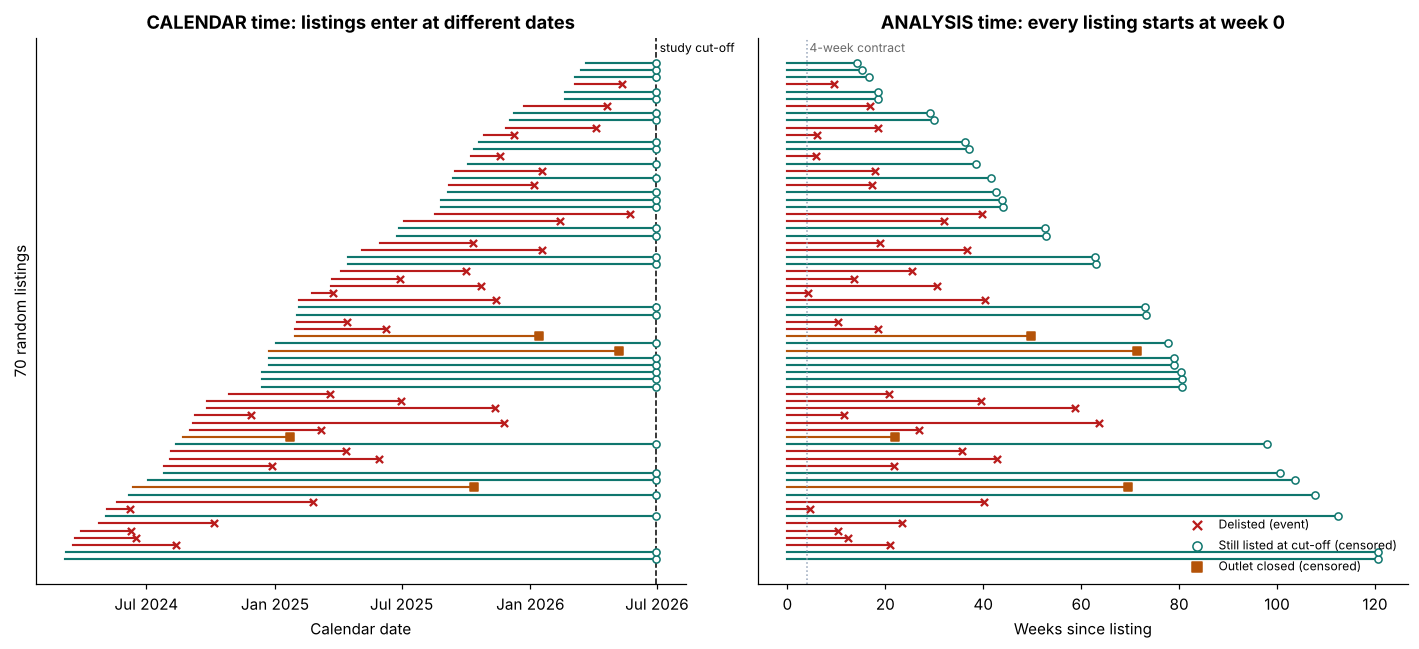

In [5]:
rng = np.random.default_rng(7)
samp = df.iloc[np.sort(rng.choice(len(df), 70, replace=False))].sort_values("listing_date").reset_index(drop=True)
col = samp.status.map({"Delisted": RED, "Censored: still listed at cut-off": TEAL, "Censored: outlet closed": AMBER})
mk = samp.status.map({"Delisted": "x", "Censored: still listed at cut-off": "o", "Censored: outlet closed": "s"})

fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for i, r in samp.iterrows():
    ax[0].plot([r.listing_date, r.exit_date], [i, i], color=col[i], lw=1.4)
    ax[0].scatter(r.exit_date, i, color=col[i], marker=mk[i], s=22, facecolors=col[i] if mk[i] != "o" else "white", zorder=3)
    ax[1].plot([0, r.weeks_listed], [i, i], color=col[i], lw=1.4)
    ax[1].scatter(r.weeks_listed, i, color=col[i], marker=mk[i], s=22, facecolors=col[i] if mk[i] != "o" else "white", zorder=3)
ax[0].axvline(CUTOFF, color="black", ls="--", lw=1); ax[0].text(CUTOFF, len(samp) + .5, " study cut-off", fontsize=8)
ax[0].set(title="CALENDAR time: listings enter at different dates", xlabel="Calendar date", ylabel="70 random listings")
ax[1].axvline(4, color=GREY, ls=":", lw=1); ax[1].text(4.5, len(samp) + .5, "4-week contract", fontsize=8, color="dimgray")
ax[1].set(title="ANALYSIS time: every listing starts at week 0", xlabel="Weeks since listing")
for lab, c, m in [("Delisted (event)", RED, "x"), ("Still listed at cut-off (censored)", TEAL, "o"), ("Outlet closed (censored)", AMBER, "s")]:
    ax[1].scatter([], [], color=c, marker=m, label=lab, facecolors="white" if m == "o" else c)
ax[1].legend(frameon=False, loc="lower right", fontsize=8)
ax[0].set_yticks([])
import matplotlib.dates as mdates
ax[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7])); ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout(); fig.savefig(OUT / "01_staggered_entry.png", dpi=150); plt.show()

**Reading the chart:** on the left, listings start on different dates and many run into the cut-off (open circles): we know they lasted *at least* that long, but not how long in total. On the right the same listings are re-aligned to their own week 0. **Survival analysis works on the right-hand clock** and treats each open circle as "survived at least this long", not as an event and not as missing data.

## 3. Why the naive approach misleads: a demonstration

The most common report in practice is "**% of listings delisted**" per launch. Let's compare it with the Kaplan-Meier estimate of the share delisted by **week 26**, which puts every launch on the same time scale.

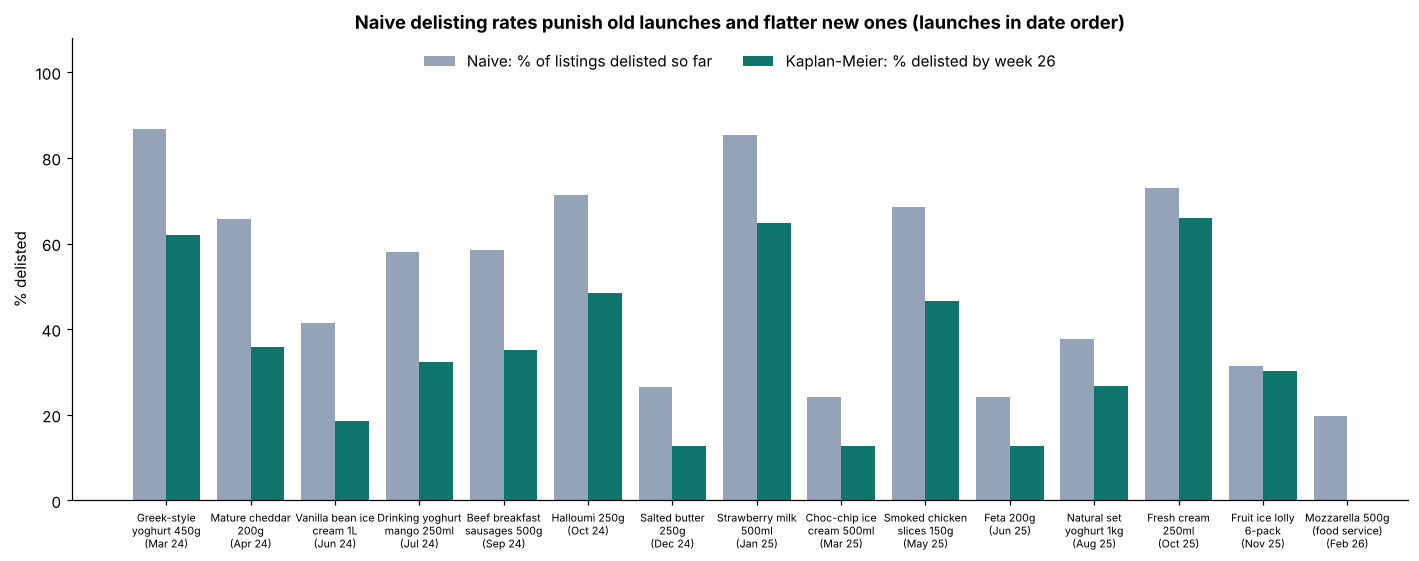

Correlation between launch order and naive % delisted: -0.49


,sku_id,sku_name,launch,listings,crude_pct_delisted,km_pct_delisted_by_wk26
0,SKU01,Greek-style yoghurt 450g,Mar 2024,517,0.868,0.621
1,SKU02,Mature cheddar 200g,Apr 2024,459,0.658,0.359
2,SKU03,Vanilla bean ice cream 1L,Jun 2024,453,0.415,0.186
3,SKU04,Drinking yoghurt mango 250ml,Jul 2024,601,0.579,0.323
4,SKU05,Beef breakfast sausages 500g,Sep 2024,457,0.584,0.350
5,SKU06,Halloumi 250g,Oct 2024,362,0.713,0.484
6,SKU07,Salted butter 250g,Dec 2024,545,0.266,0.127
7,SKU08,Strawberry milk 500ml,Jan 2025,545,0.853,0.648
8,SKU09,Choc-chip ice cream 500ml,Mar 2025,430,0.242,0.127
9,SKU10,Smoked chicken slices 150g,May 2025,418,0.684,0.467


In [6]:
rows = []
for (sku, name, launch), d in df.groupby(["sku_id", "sku_name", "launch_date"]):
    kmf = KaplanMeierFitter().fit(d.weeks_listed, d.delisted)
    reach26 = d.weeks_listed.max() >= 26
    rows.append({"sku_id": sku, "sku_name": name, "launch": launch, "listings": len(d),
                 "crude_pct_delisted": d.delisted.mean(),
                 "km_pct_delisted_by_wk26": 1 - kmf.predict(26) if reach26 else np.nan})
cohort = pd.DataFrame(rows).sort_values("launch").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.2))
x = np.arange(len(cohort))
ax.bar(x - .2, cohort.crude_pct_delisted * 100, .4, color=GREY, label="Naive: % of listings delisted so far")
ax.bar(x + .2, cohort.km_pct_delisted_by_wk26 * 100, .4, color=TEAL, label="Kaplan-Meier: % delisted by week 26")
import textwrap
ax.set_xticks(x, [textwrap.fill(n, 16) + f"\n({l:%b %y})" for n, l in zip(cohort.sku_name, cohort.launch)], fontsize=7)
ax.set(ylabel="% delisted", ylim=(0, 108), title="Naive delisting rates punish old launches and flatter new ones (launches in date order)")
ax.legend(frameon=False, ncol=2, loc="upper center")
fig.tight_layout(); fig.savefig(OUT / "02_naive_vs_km.png", dpi=150); plt.show()

r = np.corrcoef(np.arange(len(cohort)), cohort.crude_pct_delisted)[0, 1]
print(f"Correlation between launch order and naive % delisted: {r:+.2f}")
cohort.assign(launch=cohort.launch.dt.strftime("%b %Y")).round(3)

**Interpretation:** the naive delisting rate is strongly tied to launch order (correlation **−0.49**). The oldest launch, Greek-style yoghurt, shows 87% delisted "so far", but on the common week-26 yardstick its delisting rate is 62%, close to Strawberry milk (65%) and Fresh cream (66%). Naive rates overstate old launches far more than new ones: Fruit ice lolly (Nov 2025) shows 31% naive vs 30% by week 26, because almost all of its history *is* its first 26 weeks. Mozzarella (Feb 2026) can't be judged at week 26 at all yet; its naive 20% is just "too early to tell".

A league table of launches built on naive rates would wrongly favour whatever launched last.

In [7]:
naive = pd.Series({
    "naive % delisted (all listings)": df.delisted.mean(),
    "naive mean weeks on shelf (censored treated as delisted)": df.weeks_listed.mean(),
    "naive mean weeks on shelf (delisted listings only)": df.loc[df.delisted == 1, "weeks_listed"].mean(),
}).round(3)
naive.to_frame("value")

,value
naive % delisted (all listings),0.523
naive mean weeks on shelf (censored treated as delisted),43.307
naive mean weeks on shelf (delisted listings only),24.594


**Interpretation:** the two "average time on shelf" shortcuts disagree wildly, and both are wrong:

* Treating censored listings as if they were delisted at the cut-off gives **43 weeks**, an **underestimate**, because 3,304 listings are still going (or were cut short by closure).
* Averaging only the delisted listings gives **25 weeks**, a much bigger underestimate, because it keeps only the failures.

The Kaplan-Meier analysis below gives a median of about **50 weeks**, and a properly defined "mean weeks on shelf in the first year" (RMST) of **36 of 52 weeks**.

## 4. Kaplan-Meier: the survival curve of a new listing

The **Kaplan-Meier (KM) estimator** is the workhorse of survival analysis. At every week in which at least one delisting happens, it computes

$$\hat S(t) = \prod_{t_i \le t} \left(1 - \frac{d_i}{n_i}\right)$$

where $d_i$ is the number of listings delisted at time $t_i$ and $n_i$ is the number **still at risk** (listed and still being observed) just before $t_i$. Censored listings count in $n_i$ for as long as we observe them, then quietly leave the risk set. That is how KM uses *all* the information without pretending censored listings were delisted.

* **Confidence intervals** come from Greenwood's variance formula (lifelines uses the log(−log) transform so the band stays between 0 and 1).
* **Median survival** is the first time $\hat S(t) \le 0.5$: the week by which half of all listings are gone.

In [8]:
kmf = KaplanMeierFitter(label="All new-SKU listings").fit(df.weeks_listed, df.delisted)

def km_at(k, times):
    sf, ci = k.survival_function_.iloc[:, 0], k.confidence_interval_survival_function_
    return pd.DataFrame({"week": times,
                         "still_listed": [sf.asof(t) for t in times],
                         "ci_low": [ci.iloc[:, 0].asof(t) for t in times],
                         "ci_high": [ci.iloc[:, 1].asof(t) for t in times]}).set_index("week")

med_ci = median_survival_times(kmf.confidence_interval_)
print(f"Median time to delisting: {kmf.median_survival_time_:.1f} weeks "
      f"(95% CI {med_ci.iloc[0, 0]:.1f}–{med_ci.iloc[0, 1]:.1f})")
km_overall = km_at(kmf, [4, 13, 26, 52, 78, 104])
km_overall.round(3)

Median time to delisting: 49.6 weeks (95% CI 46.9–53.9)


,still_listed,ci_low,ci_high
week,,,
4,0.998,0.997,0.999
13,0.834,0.825,0.842
26,0.641,0.629,0.652
52,0.492,0.479,0.504
78,0.432,0.419,0.445
104,0.390,0.375,0.405


**Interpretation:**

* **The median new listing survives about 50 weeks** (95% CI 47–54): half of all listings are gone within a year.
* **17% are delisted within the first quarter** (S(13) = 0.83) and **36% within six months** (S(26) = 0.64).
* After a year the curve flattens: from 49% still listed at week 52 to 39% at week 104. A listing that survives its first year has become part of the outlet's core range, and the risk drops sharply. That plateau is the signature of a **decreasing hazard after an early peak**, which we look at directly in section 6.

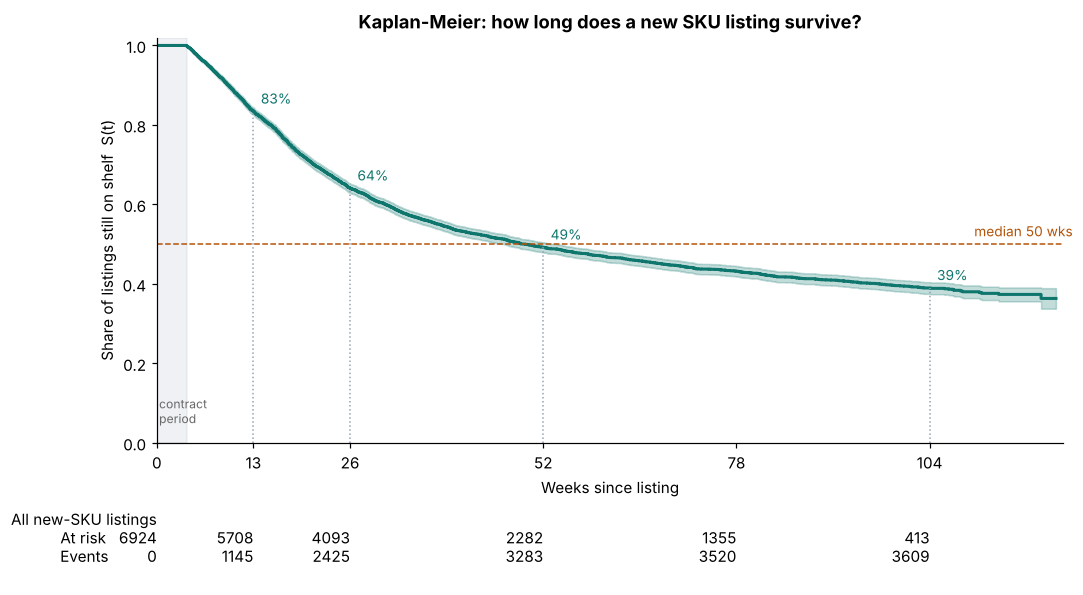

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.6))
kmf.plot_survival_function(ax=ax, color=TEAL, ci_show=True, lw=2)
for t in [13, 26, 52, 104]:
    s = kmf.predict(t); ax.plot([t, t], [0, s], color=GREY, ls=":", lw=1); ax.text(t + 1, s + .02, f"{s:.0%}", fontsize=9, color=TEAL)
ax.axhline(.5, color=AMBER, ls="--", lw=1); ax.text(110, .52, f"median {kmf.median_survival_time_:.0f} wks", color=AMBER, fontsize=9)
ax.axvspan(0, 4, color=GREY, alpha=.15); ax.text(.3, .05, "contract\nperiod", fontsize=8, color="dimgray")
ax.set(ylim=(0, 1.02), xlim=(0, 122), xlabel="Weeks since listing", ylabel="Share of listings still on shelf  S(t)",
       title="Kaplan-Meier: how long does a new SKU listing survive?")
ax.get_legend().remove(); ax.set_xticks([0, 13, 26, 52, 78, 104])
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events"], xticks=[0, 13, 26, 52, 78, 104])
fig.tight_layout(); fig.savefig(OUT / "03_km_overall.png", dpi=150); plt.show()

The table under the chart shows the **number at risk** and the cumulative number of delistings. By week 104 only 413 listings are still being observed (most launches haven't been on sale that long), so the right-hand tail is estimated from fewer listings and the confidence band widens.

### Kaplan-Meier by key groups

We compare survival curves for the drivers the business can act on (launch support, merchandiser coverage, early sell-through) and the ones it chooses (channel). Early sell-through is grouped into four bands for display; the models later use it as a continuous variable.

In [10]:
df["sellthrough_band"] = pd.cut(df.sellthrough_4wk_pct, [0, 30, 50, 70, 100], include_lowest=True,
                                labels=["<30%", "30–50%", "50–70%", "≥70%"])
df["trade_promo_lbl"] = df.trade_promo.map({0: "No promo", 1: "Promo funded"})
df["pos_lbl"] = df.pos_material.map({0: "No POS", 1: "POS / planogram"})
df["merch_lbl"] = df.has_merchandiser.map({0: "No merchandiser", 1: "Merchandiser"})

def km_group_table(col):
    out = []
    for g, d in df.groupby(col, observed=True):
        k = KaplanMeierFitter().fit(d.weeks_listed, d.delisted)
        ci = median_survival_times(k.confidence_interval_)
        out.append({"variable": col, "group": str(g), "listings": len(d), "delisted": int(d.delisted.sum()),
                    "median_wks": k.median_survival_time_, "median_ci_low": ci.iloc[0, 0], "median_ci_high": ci.iloc[0, 1],
                    "S(13)": k.predict(13), "S(26)": k.predict(26), "S(52)": k.predict(52)})
    return pd.DataFrame(out)

km_tab = pd.concat([km_group_table(c) for c in ["trade_promo_lbl", "pos_lbl", "merch_lbl", "sellthrough_band", "channel", "category"]],
                   ignore_index=True)
km_tab.to_csv(OUT / "km_medians_by_group.csv", index=False)
km_tab.round(3)

,variable,group,listings,delisted,median_wks,median_ci_low,median_ci_high,S(13),S(26),S(52)
0,trade_promo_lbl,No promo,4096,2432,34.14,32.14,37.00,0.761,0.567,0.428
1,trade_promo_lbl,Promo funded,2828,1188,93.71,78.00,107.29,0.940,0.747,0.585
2,pos_lbl,No POS,3764,2344,30.57,28.71,32.29,0.775,0.545,0.386
3,pos_lbl,POS / planogram,3160,1276,111.00,101.57,inf,0.904,0.754,0.616
4,merch_lbl,Merchandiser,3012,1161,119.00,110.71,inf,0.910,0.774,0.632
5,merch_lbl,No merchandiser,3912,2459,29.57,28.29,31.57,0.775,0.537,0.382
6,sellthrough_band,<30%,1612,1446,14.29,13.71,15.00,0.549,0.210,0.069
7,sellthrough_band,30–50%,1394,983,28.43,26.57,30.00,0.808,0.535,0.295
8,sellthrough_band,50–70%,1486,666,79.71,67.86,93.43,0.931,0.764,0.592
9,sellthrough_band,≥70%,2432,525,inf,inf,inf,0.978,0.906,0.811


**Interpretation (unadjusted, one variable at a time):**

| Driver | Median weeks on shelf | Still listed at week 52 |
|---|---|---|
| Promo funded vs not | **94** vs 34 | 59% vs 43% |
| POS / planogram vs none | **111** vs 31 | 62% vs 39% |
| Merchandiser vs none | **119** vs 30 | 63% vs 38% |
| Sell-through ≥ 70% vs < 30% | not reached vs **14** | 81% vs 7% |
| Supermarket vs duka | not reached vs **22** | 64% vs 29% |

Early sell-through is by far the sharpest separator: listings that sold less than 30% of their opening stock in the first month have a median life of just **14 weeks**, and only **7%** survive a year. By category, flavoured milk (median 18 weeks) is weakest; ice cream (69% still listed at week 52) and butter & cream are strongest. Where the median is "inf", fewer than half of that group's listings had been delisted by the end of follow-up, so the median can't be estimated yet.

These comparisons are **confounded**: promo funding, POS and merchandisers all go disproportionately to supermarkets, which are also the most loyal channel. The Cox model will separate them.

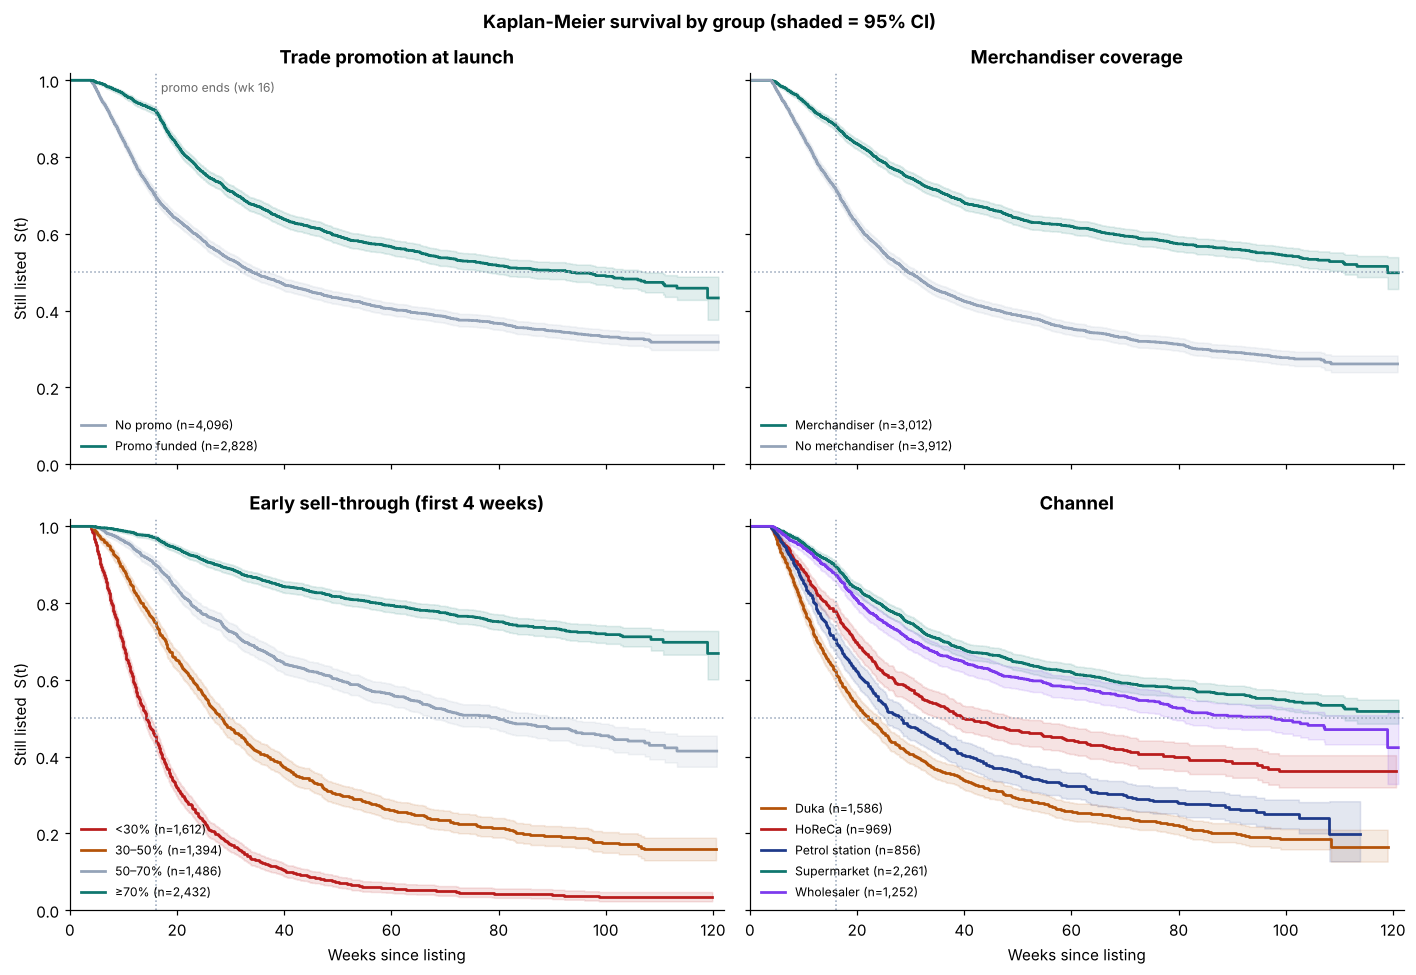

In [11]:
panels = [("trade_promo_lbl", "Trade promotion at launch", [GREY, TEAL]),
          ("merch_lbl", "Merchandiser coverage", [TEAL, GREY]),   # groups sort as "Merchandiser", "No merchandiser"
          ("sellthrough_band", "Early sell-through (first 4 weeks)", [RED, AMBER, GREY, TEAL]),
          ("channel", "Channel", [AMBER, RED, NAVY, TEAL, PURPLE])]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (colname, title, cols) in zip(axes.flat, panels):
    for (g, d), c in zip(df.groupby(colname, observed=True), cols):
        k = KaplanMeierFitter(label=f"{g} (n={len(d):,})").fit(d.weeks_listed, d.delisted)
        k.plot_survival_function(ax=ax, color=c, ci_show=True, ci_alpha=.12, lw=1.8)
    ax.axhline(.5, color=GREY, ls=":", lw=1); ax.axvline(PROMO_WEEKS, color=GREY, ls=":", lw=1)
    ax.set(title=title, ylim=(0, 1.02), xlim=(0, 122), xlabel="Weeks since listing", ylabel="Still listed  S(t)")
    ax.legend(frameon=False, fontsize=8, loc="lower left")
axes[0, 0].text(PROMO_WEEKS + 1, .97, "promo ends (wk 16)", fontsize=8, color="dimgray")
fig.suptitle("Kaplan-Meier survival by group (shaded = 95% CI)", fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "04_km_by_group.png", dpi=150); plt.show()

**Reading the charts:** look at the **trade-promotion panel**. Up to week 16 the promo-funded curve barely drops while the unfunded curve falls steeply. Right after week 16, when the funding stops, the promo curve **bends down sharply**: from then on the two curves fall at a similar pace. That shape is the first hint that the promo effect is **not proportional over time**. The sell-through panel shows four clearly separated curves in perfect dose-response order.

## 5. Log-rank tests: are the differences real?

The **log-rank test** asks whether two or more survival curves differ by more than chance. At every event time it compares the *observed* number of delistings in each group with the number *expected* if all groups shared one survival curve, then adds up the differences over the whole follow-up.

* It is most powerful when one group's hazard is a constant multiple of the other's (proportional hazards). If curves **cross**, early and late differences can cancel out and the test loses power.
* With more than two groups, the **multivariate (k-sample) log-rank test** checks "any difference at all". **Pairwise tests** show *which* groups differ; we correct their p-values for multiple testing with the **Holm** method.
* Log-rank tests are **univariate**: they don't adjust for confounders. Supermarkets get more promo funding *and* have different baseline risk, for example. The Cox model in section 7 separates these.

In [12]:
lr_rows = []
for colname in ["trade_promo", "pos_material", "has_merchandiser"]:
    a, b = df[df[colname] == 1], df[df[colname] == 0]
    t = logrank_test(a.weeks_listed, b.weeks_listed, a.delisted, b.delisted)
    lr_rows.append({"comparison": f"{colname}: 1 vs 0", "test": "log-rank (2 groups)", "df": 1,
                    "chi2": t.test_statistic, "p_value": t.p_value})
for colname in ["channel", "category", "sellthrough_band"]:
    t = multivariate_logrank_test(df.weeks_listed, df[colname].astype(str), df.delisted)
    lr_rows.append({"comparison": colname, "test": "multivariate log-rank", "df": df[colname].nunique() - 1,
                    "chi2": t.test_statistic, "p_value": t.p_value})
logrank = pd.DataFrame(lr_rows)
logrank.to_csv(OUT / "logrank_tests.csv", index=False)
logrank.assign(chi2=logrank.chi2.round(1), p_value=logrank.p_value.map(lambda p: f"{p:.1e}"))

,comparison,test,df,chi2,p_value
0,trade_promo: 1 vs 0,log-rank (2 groups),1,247.4,9.7e-56
1,pos_material: 1 vs 0,log-rank (2 groups),1,424.1,3.2e-94
2,has_merchandiser: 1 vs 0,log-rank (2 groups),1,519.6,5.1e-115
3,channel,multivariate log-rank,4,785.3,1.2e-168
4,category,multivariate log-rank,5,608.6,2.8e-129
5,sellthrough_band,multivariate log-rank,3,3811.5,0.0e+00


**Interpretation:** every comparison is highly significant (p < 10⁻⁵⁰). With almost 7,000 listings, statistical significance is easy. The **size** of the chi-square shows which variables separate survival most: early sell-through bands (χ² = 3,812) dwarf everything else, followed by channel (785), category (609), merchandiser coverage (520), POS (424) and trade promo (247). The promo statistic is the smallest of the launch-support levers, partly because its curves converge after week 16, so the early advantage and later catch-up partly offset each other in a whole-period test.

In [13]:
pw = pairwise_logrank_test(df.weeks_listed, df.channel, df.delisted).summary.reset_index()
pw.columns = ["group_a", "group_b", "chi2", "p_value", "-log2(p)"]
# Holm step-down adjustment
order_ = np.argsort(pw.p_value.values); m = len(pw); adj = np.empty(m); running = 0
for rank_, i in enumerate(order_):
    running = max(running, min(1, (m - rank_) * pw.p_value.values[i])); adj[i] = running
pw["p_holm"] = adj
med = km_tab[km_tab.variable == "channel"].set_index("group").median_wks
pw["median_a"], pw["median_b"] = pw.group_a.map(med), pw.group_b.map(med)
pw[["group_a", "median_a", "group_b", "median_b", "chi2", "p_holm"]].round({"chi2": 1, "median_a": 1, "median_b": 1}) \
  .assign(p_holm=lambda d: d.p_holm.map(lambda p: f"{p:.2g}"))

,group_a,median_a,group_b,median_b,chi2,p_holm
0,Duka,22.1,HoReCa,39.7,92.8,2.8e-21
1,Duka,22.1,Petrol station,28.1,17.0,7.4e-05
2,Duka,22.1,Supermarket,inf,631.5,2.3e-138
3,Duka,22.1,Wholesaler,98.0,336.5,3.4e-74
4,HoReCa,39.7,Petrol station,28.1,24.6,2.2e-06
5,HoReCa,39.7,Supermarket,inf,108.8,1.1e-24
6,HoReCa,39.7,Wholesaler,98.0,46.7,3.3e-11
7,Petrol station,28.1,Supermarket,inf,287.6,1.3e-63
8,Petrol station,28.1,Wholesaler,98.0,154.6,1.2e-34
9,Supermarket,inf,Wholesaler,98.0,8.0,0.0046


**Interpretation:** after Holm correction **all ten channel pairs differ significantly**. The ranking is clear: **supermarkets and wholesalers** keep new SKUs longest, **HoReCa** is in the middle (median 40 weeks), and **petrol stations** (28) and **dukas** (22) delist fastest. The closest pair is supermarket vs wholesaler (χ² = 8.0, p = 0.005).

## 6. Nelson-Aalen: the cumulative hazard and the *shape* of risk over time

KM tells us *how many* listings survive. The **hazard** tells us *when* the danger is greatest. The **Nelson-Aalen estimator** of the cumulative hazard is

$$\hat H(t) = \sum_{t_i \le t} \frac{d_i}{n_i}$$

Its slope is the hazard. A straight line would mean a constant weekly delisting rate; a curve that steepens and then flattens means risk peaks at some point and then fades. Smoothing the increments with a kernel gives an estimate of the hazard itself, here per 100 listings per week.

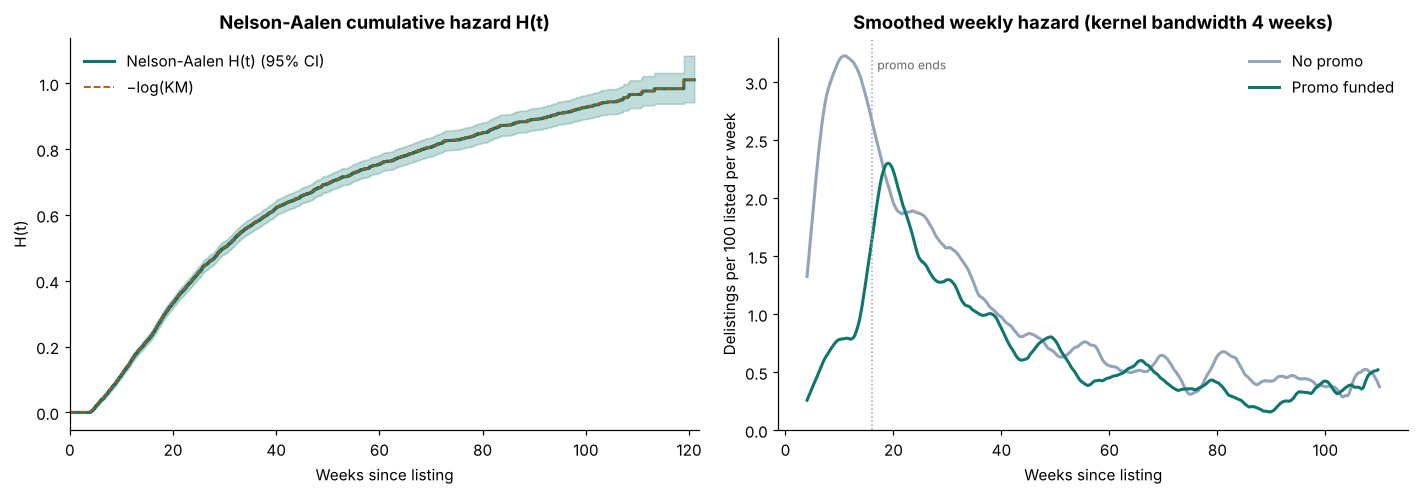

Peak hazard week: {'no_promo': 11.0, 'promo': 19.0} | peak level per 100/wk: {'no_promo': np.float64(3.23), 'promo': np.float64(2.3)}


,no_promo,promo
8,2.95,0.67
12,3.19,0.78
16,2.67,1.64
20,1.96,2.23
26,1.83,1.42
39,1.01,0.97
52,0.65,0.61
78,0.47,0.40
104,0.30,0.37


In [14]:
naf = NelsonAalenFitter(label="Nelson-Aalen H(t) (95% CI)").fit(df.weeks_listed, df.delisted)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
naf.plot_cumulative_hazard(ax=ax[0], color=TEAL, lw=2)
ax[0].plot(kmf.survival_function_.index, -np.log(kmf.survival_function_.iloc[:, 0].clip(1e-9)), color=AMBER, ls="--", lw=1.2, label="−log(KM)")
ax[0].set(title="Nelson-Aalen cumulative hazard H(t)", xlabel="Weeks since listing", ylabel="H(t)", xlim=(0, 122))
ax[0].legend(frameon=False)

bw = 4
haz_rows = {}
for g, c in [(0, GREY), (1, TEAL)]:
    d = df[df.trade_promo == g]
    nf = NelsonAalenFitter().fit(d.weeks_listed, d.delisted)
    sh = nf.smoothed_hazard_(bw)
    sh = sh[(sh.index >= 4) & (sh.index <= 110)]   # no delisting is possible before week 4 (contract period)
    ax[1].plot(sh.index, sh.iloc[:, 0] * 100, color=c, lw=2, label=["No promo", "Promo funded"][g])
    haz_rows[["no_promo", "promo"][g]] = sh.iloc[:, 0]
ax[1].axvline(PROMO_WEEKS, color=GREY, ls=":", lw=1); ax[1].text(PROMO_WEEKS + 1, ax[1].get_ylim()[1] * .92, "promo ends", fontsize=8, color="dimgray")
ax[1].set(title=f"Smoothed weekly hazard (kernel bandwidth {bw} weeks)", xlabel="Weeks since listing",
          ylabel="Delistings per 100 listed per week")
ax[1].legend(frameon=False); ax[1].set_ylim(bottom=0)
fig.tight_layout(); fig.savefig(OUT / "05_hazard.png", dpi=150); plt.show()

hz = pd.DataFrame(haz_rows) * 100
peak = hz.idxmax()
print("Peak hazard week:", {k: round(v, 1) for k, v in peak.items()},
      "| peak level per 100/wk:", {k: round(hz[k].max(), 2) for k in hz})
hz.reindex([8, 12, 16, 20, 26, 39, 52, 78, 104], method="nearest").round(2)

**Interpretation:**

* The cumulative hazard is steep for the first 30-40 weeks and then flattens: **the danger zone is the first two to three quarters after listing**. (The Nelson-Aalen and −log KM curves lie on top of each other, as they should with this much data.)
* For **unfunded** listings the hazard peaks around **week 11** at about **3.2 delistings per 100 listings per week**: the first range review.
* For **promo-funded** listings the hazard is held down to about **0.7-0.8 per 100 per week** while the promotion runs, then **jumps to a peak of about 2.3 per 100 at week 19**, just after the funding stops. By weeks 39-52 the two groups have almost the same hazard (1.01 vs 0.97 per 100 per week at week 39, 0.65 vs 0.61 at week 52).

So trade promotion doesn't remove the delisting risk; it **postpones** much of it until the money stops. A single hazard ratio can't describe that. Note also that the overall hazard *rises then falls*, which matters when we pick a parametric model.

## 7. Cox proportional hazards model: what drives delisting, all else equal?

The **Cox model** relates the hazard to the covariates without assuming any shape for the baseline hazard:

$$h(t \mid x) = h_0(t)\, \exp(\beta_1 x_1 + \dots + \beta_p x_p)$$

* $h_0(t)$ is the baseline hazard: the hump we saw in section 6, left completely unspecified (that's why Cox is called *semi-parametric*).
* $e^{\beta_j}$ is a **hazard ratio**: the factor by which the delisting rate is multiplied for a one-unit increase in $x_j$, **holding all other covariates fixed**, at *every* point in time. That last phrase is the **proportional hazards (PH) assumption**, which we test in section 8.
* The coefficients are estimated by maximising the **partial likelihood**, which only uses the *ordering* of event times. Tied event times are handled with **Efron's method** (lifelines' default; the R script uses `ties = "efron"` so results match).

### Covariate coding (identical in the R script)

| Covariate | Unit of the hazard ratio |
|---|---|
| `sellthrough_per10pp` | per +10 percentage points of 4-week sell-through |
| `trade_promo`, `pos_material`, `has_merchandiser` | yes vs no |
| `price_index_per10` | per +10 index points (≈ 10% more expensive than the category) |
| `retailer_margin_pp` | per +1 percentage point of retailer margin |
| `distance_per100km` | per +100 km from the depot |
| `log2_shelf_life` | per **doubling** of shelf life |
| `channel_*` | vs **Supermarket** (reference) |
| `category_*` | vs **Yoghurt** (reference) |

We fit on **all** listings here because the goal is inference (which drivers matter and by how much). Predictive accuracy is assessed on a held-out set in section 10.

In [15]:
CHANNELS = ["Wholesaler", "Duka", "HoReCa", "Petrol station"]           # reference: Supermarket
CATEGORIES = ["Cheese", "Ice cream", "Deli", "Butter & cream", "Flavoured milk"]   # reference: Yoghurt
clean = lambda s: s.replace(" & ", "_").replace(" ", "_")

def design(d, sellthrough=True):
    X = pd.DataFrame(index=d.index)
    if sellthrough:
        X["sellthrough_per10pp"] = d.sellthrough_4wk_pct / 10
    X["trade_promo"] = d.trade_promo
    X["pos_material"] = d.pos_material
    X["has_merchandiser"] = d.has_merchandiser
    X["price_index_per10"] = (d.price_index - 100) / 10
    X["retailer_margin_pp"] = d.retailer_margin_pct
    X["distance_per100km"] = d.distance_km / 100
    X["log2_shelf_life"] = np.log2(d.shelf_life_days)
    for c in CHANNELS:
        X[f"channel_{clean(c)}"] = (d.channel == c).astype(int)
    for c in CATEGORIES:
        X[f"category_{clean(c)}"] = (d.category == c).astype(int)
    return X

LABELS = {"sellthrough_per10pp": "Sell-through, +10pp (wk 1-4)", "trade_promo": "Trade promo funded",
          "pos_material": "POS / planogram", "has_merchandiser": "Merchandiser coverage",
          "price_index_per10": "Price index, +10 pts", "retailer_margin_pp": "Retailer margin, +1pp",
          "distance_per100km": "Distance to depot, +100 km", "log2_shelf_life": "Shelf life, x2",
          **{f"channel_{clean(c)}": f"Channel: {c}" for c in CHANNELS},
          **{f"category_{clean(c)}": f"Category: {c}" for c in CATEGORIES},
          "promo_wk0_16": "Trade promo, weeks 0-16", "promo_after_16": "Trade promo, after week 16"}

D = design(df).assign(weeks_listed=df.weeks_listed, delisted=df.delisted)
cph = CoxPHFitter().fit(D, duration_col="weeks_listed", event_col="delisted")
s = cph.summary
hr = pd.DataFrame({"coef": s["coef"], "se": s["se(coef)"], "hazard_ratio": s["exp(coef)"],
                   "ci_low": s["exp(coef) lower 95%"], "ci_high": s["exp(coef) upper 95%"], "p_value": s["p"]})
hr.index.name = "feature"
hr.to_csv(OUT / "cox_hazard_ratios.csv")
print(f"Cox PH: n = {cph._n_examples:,}, events = {int(D.delisted.sum()):,}, "
      f"partial log-likelihood = {cph.log_likelihood_:.1f}, concordance (in-sample) = {cph.concordance_index_:.3f}")
hr.sort_values("hazard_ratio").round(3)

Cox PH: n = 6,924, events = 3,620, partial log-likelihood = -27943.6, concordance (in-sample) = 0.808


,coef,se,hazard_ratio,ci_low,ci_high,p_value
feature,,,,,,
has_merchandiser,-0.403,0.040,0.669,0.619,0.723,0.000
log2_shelf_life,-0.359,0.028,0.699,0.661,0.739,0.000
sellthrough_per10pp,-0.347,0.008,0.707,0.695,0.718,0.000
pos_material,-0.321,0.039,0.726,0.672,0.784,0.000
trade_promo,-0.260,0.037,0.771,0.717,0.830,0.000
channel_Wholesaler,-0.234,0.073,0.792,0.687,0.913,0.001
category_Butter_cream,-0.179,0.058,0.836,0.746,0.937,0.002
retailer_margin_pp,-0.036,0.006,0.964,0.954,0.975,0.000
category_Deli,-0.035,0.055,0.966,0.867,1.075,0.524


**Interpretation, in plain English** (each effect holds the other covariates constant):

* **Early sell-through is the strongest lever:** every extra **10 percentage points** of stock sold in the first 4 weeks cuts the weekly delisting rate by **29%** (HR 0.71, 95% CI 0.70-0.72). A listing at 80% sell-through has about 0.71³ ≈ **0.35×** the hazard of one at 50%.
* **Launch support, over and above sell-through:** a **merchandiser** cuts the hazard by **33%** (HR 0.67), **POS / planogram placement** by **27%** (HR 0.73) and **trade promotion** by **23%** on average (HR 0.77). The promo HR is a time-averaged figure that section 8 shows to be misleading.
* **Price and terms:** each **10 index points above the category price** raises the hazard by **33%** (HR 1.33). Each **extra point of retailer margin** lowers it by about **4%** (HR 0.96), so a 5-point margin improvement is worth about 0.96⁵ ≈ 17% lower hazard.
* **Logistics:** each **100 km from the depot** adds **16%** (HR 1.16). Upcountry outlets get patchier deliveries.
* **Channel** (vs supermarkets): **petrol stations +47%**, **dukas +32%**, wholesalers −21%; HoReCa is not significantly different.
* **Product:** each **doubling of shelf life** lowers the hazard by **30%** (HR 0.70). Holding shelf life constant, **ice cream** has a 76% higher hazard than yoghurt (freezer space is scarce and contested), and **flavoured milk** a 47% higher one. In real terms, though, ice cream's 365-day shelf life more than offsets this: its overall survival is the best of any category (section 4).

The model's in-sample concordance is **0.81**: for 81% of comparable pairs of listings, the one delisted first had the higher predicted risk.

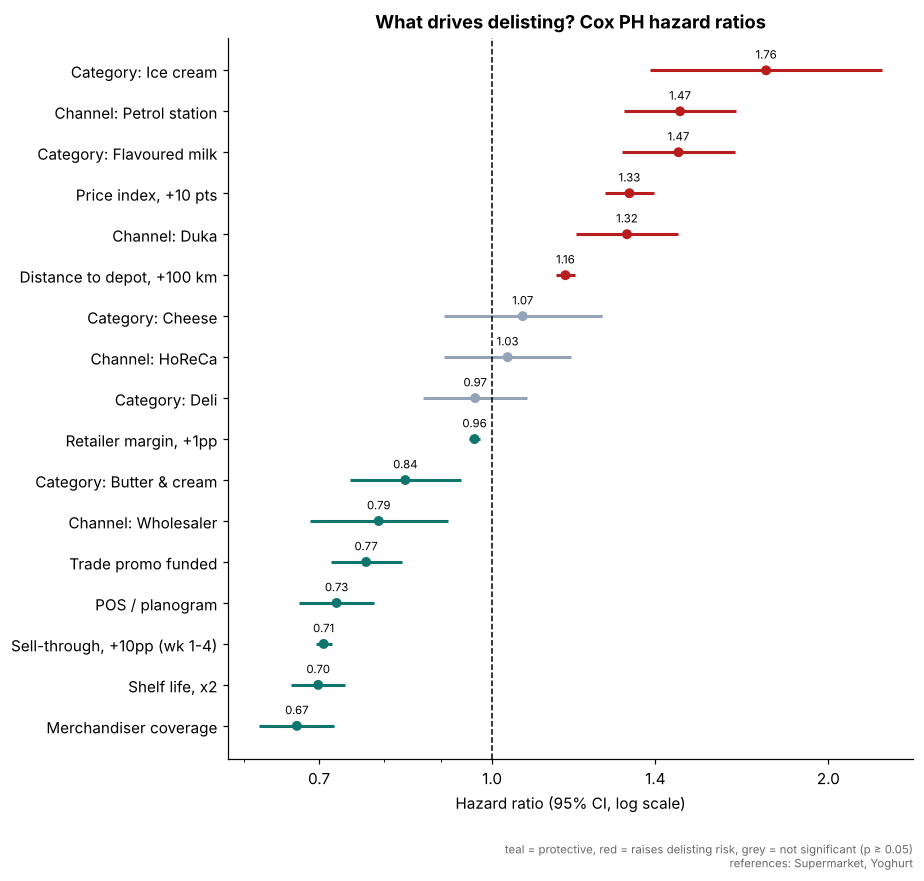

In [16]:
def forest(tab, title, fname, xlabel="Hazard ratio (95% CI, log scale)", ref_note=True):
    o = tab.sort_values("hazard_ratio")
    fig, ax = plt.subplots(figsize=(8.5, .38 * len(o) + 1.6))
    c = np.where(o.p_value < .05, np.where(o.hazard_ratio > 1, RED, TEAL), GREY)
    y = np.arange(len(o))
    ax.hlines(y, o.ci_low, o.ci_high, color=c, lw=2)
    ax.scatter(o.hazard_ratio, y, color=c, s=30, zorder=3)
    for yi, h in enumerate(o.hazard_ratio):
        ax.text(h, yi + .22, f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)
    ax.axvline(1, color="black", ls="--", lw=1); ax.set_xscale("log")
    ax.set_yticks(y, [LABELS.get(i, i) for i in o.index])
    ticks = [.25, .35, .5, .7, 1, 1.4, 2, 2.8]
    ax.set_xticks([t for t in ticks if o.ci_low.min() * .9 <= t <= o.ci_high.max() * 1.25]); ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
    ax.set(xlabel=xlabel, title=title)
    if ref_note:
        ax.text(1.0, -.08 - 1.2 / len(o), "teal = protective, red = raises delisting risk, grey = not significant (p ≥ 0.05)\n"
                "references: Supermarket, Yoghurt", transform=ax.transAxes, ha="right", fontsize=7.5, color="dimgray")
    fig.tight_layout(); fig.savefig(OUT / fname, dpi=150); plt.show()

forest(hr, "What drives delisting? Cox PH hazard ratios", "06_cox_forest.png")

In [17]:
# Sensitivity: listings of the same SKU share an unobserved "appeal". Cluster-robust (sandwich) standard errors by SKU
# show how much less certain the SKU-level covariates really are when there are only 15 launches.
cph_rob = CoxPHFitter().fit(D.assign(sku=df.sku_id), "weeks_listed", "delisted", cluster_col="sku")
rob = pd.DataFrame({"hazard_ratio": hr.hazard_ratio, "se_model": hr.se, "se_robust_by_sku": cph_rob.summary["se(coef)"],
                    "p_model": hr.p_value, "p_robust": cph_rob.summary["p"]})
rob["se_inflation"] = rob.se_robust_by_sku / rob.se_model
rob.round(3).sort_values("se_inflation", ascending=False)

,hazard_ratio,se_model,se_robust_by_sku,p_model,p_robust,se_inflation
category_Butter_cream,0.836,0.058,0.148,0.002,0.226,2.547
category_Cheese,1.065,0.083,0.208,0.446,0.762,2.515
category_Deli,0.966,0.055,0.127,0.524,0.783,2.311
category_Flavoured_milk,1.468,0.059,0.130,0.000,0.003,2.193
category_Ice_cream,1.759,0.122,0.262,0.000,0.031,2.156
log2_shelf_life,0.699,0.028,0.052,0.000,0.000,1.832
sellthrough_per10pp,0.707,0.008,0.013,0.000,0.000,1.480
price_index_per10,1.327,0.026,0.037,0.000,0.000,1.411
channel_Petrol_station,1.473,0.059,0.074,0.000,0.000,1.264
trade_promo,0.771,0.037,0.046,0.000,0.000,1.242


**Interpretation:** this is an important honesty check. Listings of the same SKU are **not independent**: they share an unobserved "appeal" (some launches are simply better products). With only 15 launches, the **SKU-level covariates** (category, shelf life) are really estimated from 15 data points, not 6,924.

* Clustering by SKU inflates the standard errors of the **category** terms **2.2-2.5×**. **Butter & cream** is no longer significant (p = 0.23); ice cream (p = 0.03) and flavoured milk (p = 0.003) survive. **Shelf life** stays significant, but its HR of 0.70 per doubling should be read as "longer-life SKUs do better", not as a precise causal number.
* The **outlet- and listing-level** levers (sell-through, promo, POS, merchandiser, price, margin, distance, channel) are barely affected: the effective sample size is large for them.

In [18]:
# Sensitivity 2: is censoring by outlet closure informative?
# (a) Cause-specific Cox model for CLOSURE (delisting treated as censoring): if launch conditions or sell-through
#     predicted closure, closures would not be "random" with respect to delisting risk.
closed = (df.status == "Censored: outlet closed").astype(int)
cc = CoxPHFitter().fit(D.drop(columns="delisted").assign(closed=closed), "weeks_listed", "closed")
# (b) Worst case: pretend every closure was a delisting and refit the main model.
cph_wc = CoxPHFitter().fit(D.assign(delisted=D.delisted | closed), "weeks_listed", "delisted")
keys = ["sellthrough_per10pp", "trade_promo", "pos_material", "has_merchandiser", "price_index_per10", "channel_Duka"]
pd.DataFrame({"HR_closure_hazard": cc.summary.loc[keys, "exp(coef)"], "p_closure": cc.summary.loc[keys, "p"],
              "HR_main": hr.loc[keys, "hazard_ratio"], "HR_if_closures_were_delistings": cph_wc.summary.loc[keys, "exp(coef)"]}).round(3)

,HR_closure_hazard,p_closure,HR_main,HR_if_closures_were_delistings
sellthrough_per10pp,0.998,0.951,0.707,0.721
trade_promo,1.297,0.093,0.771,0.796
pos_material,1.181,0.305,0.726,0.745
has_merchandiser,0.803,0.182,0.669,0.675
price_index_per10,0.915,0.437,1.327,1.306
channel_Duka,7.286,0.000,1.320,1.431


**Interpretation:** censoring by outlet closure looks **non-informative** for the things we care about:

* In a model for the **closure** hazard, sell-through (HR 1.00, p = 0.95), trade promo (1.30, p = 0.09), POS, merchandiser and price are all non-significant. Only **channel** predicts closure: dukas close about 7× faster than supermarkets, which is why they lose more listings to closure.
* Even in the **worst case** (every closure counted as a delisting), the key hazard ratios hardly move: sell-through 0.71 → 0.72, trade promo 0.77 → 0.80, merchandiser 0.67 → 0.68, price 1.33 → 1.31. The duka effect grows from 1.32 to 1.43, exactly as expected when duka closures are added as events.

With only 195 closures (2.8%), the conclusions don't depend on how they are treated.

## 8. Checking the proportional hazards assumption, and fixing it

The Cox model assumes each hazard ratio is **constant over time**. Launch promotions are a textbook reason to doubt that: promo funding runs for 16 weeks and then stops. If a promo protects a listing only while it lasts, a single "average" hazard ratio would hide a strong early effect and whatever happens afterwards.

### Tools

1. **Schoenfeld residual test (Grambsch-Therneau).** For every delisting, the Schoenfeld residual compares the covariate of the listing that was delisted with the risk-weighted average covariate of everything still at risk. If PH holds, the (scaled) residuals show no trend over time. The test correlates them with a transform of time (here the Kaplan-Meier transform, the same default as R's `cox.zph`; lifelines also offers a rank transform).
2. **Plot of scaled Schoenfeld residuals vs time.** Adding the estimated coefficient to each scaled residual gives a local estimate of $\beta(t)$, so the plot shows how the log-hazard ratio *moves* over time.
3. **log(−log S(t)) plot.** Under PH, the curves for two groups are parallel on this scale.

With almost 7,000 listings the test has power to flag even tiny departures, so we look at **effect size** (how much the hazard ratio actually changes) and not just p-values.

In [19]:
ph_km = proportional_hazard_test(cph, D, time_transform="km").summary
ph_rank = proportional_hazard_test(cph, D, time_transform="rank").summary
ph = pd.DataFrame({"chi2_km": ph_km.test_statistic, "p_km": ph_km.p, "chi2_rank": ph_rank.test_statistic, "p_rank": ph_rank.p})
ph.index.name = "feature"
ph.to_csv(OUT / "ph_tests.csv")
ph.sort_values("p_km").round(4)

,chi2_km,p_km,chi2_rank,p_rank
feature,,,,
trade_promo,124.2055,0.0000,129.6353,0.0000
sellthrough_per10pp,5.5002,0.0190,5.4689,0.0194
category_Butter_cream,5.4010,0.0201,5.1238,0.0236
channel_Petrol_station,3.5043,0.0612,3.3048,0.0691
category_Ice_cream,2.3436,0.1258,2.2594,0.1328
category_Deli,1.2020,0.2729,1.1946,0.2744
retailer_margin_pp,0.9397,0.3323,1.1868,0.2760
distance_per100km,0.5308,0.4663,0.5499,0.4584
price_index_per10,0.5125,0.4740,0.3575,0.5499


**Interpretation:** **trade promotion fails the PH test overwhelmingly** (χ² = 124, p < 0.0001). Nothing else comes close: sell-through (p = 0.019) and butter & cream (p = 0.020) are borderline at the 5% level and pass at 1%; every other covariate passes comfortably. The KM and rank time transforms agree. The R script (`cox.zph`, which uses an exact score test) flags the same promo violation (χ² = 144) and is somewhat stricter on sell-through (p = 0.0004); its estimated change over time is small next to the promo effect.

In [20]:
# lifelines' built-in helper prints advice for every covariate that fails (threshold p < 0.01)
cph.check_assumptions(D, p_value_threshold=0.01, show_plots=False)

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'trade_promo' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['trade_promo', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[]

Mean scaled Schoenfeld residual for trade_promo: -0.0000 (≈ 0, so beta(t) = residual + coefficient)


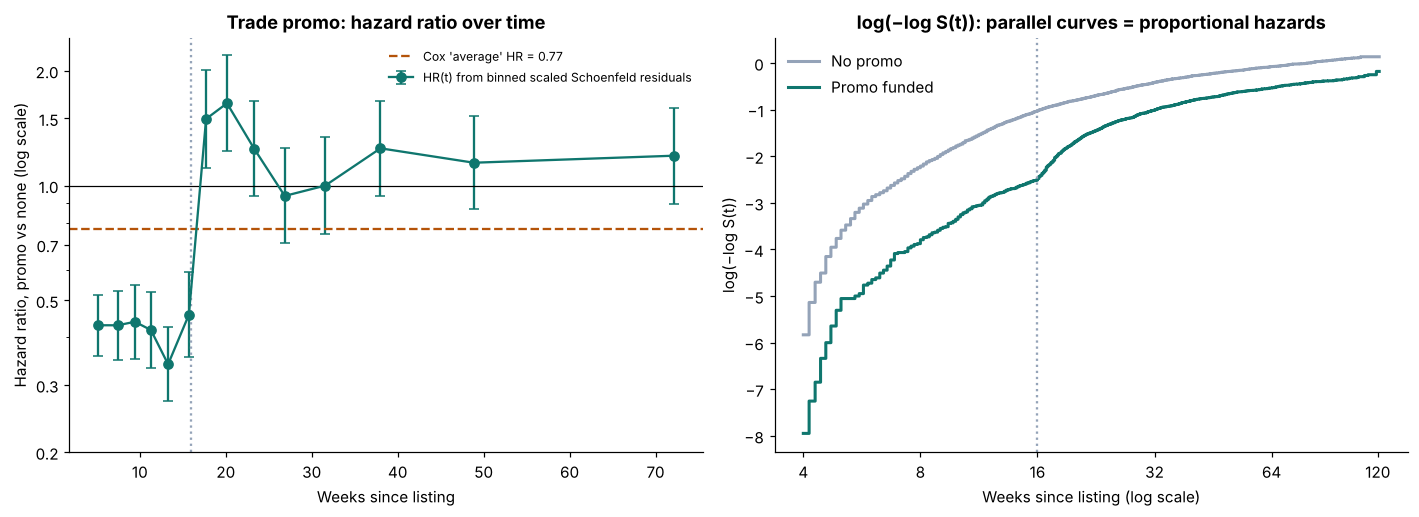

,t,n,HR_t
weeks_listed,,,
"(3.999, 6.14]",5.14,264,0.43
"(6.14, 8.29]",7.43,265,0.43
"(8.29, 10.29]",9.43,261,0.44
"(10.29, 12.14]",11.29,257,0.42
"(12.14, 14.43]",13.29,249,0.34
"(14.43, 16.71]",15.71,261,0.46
"(16.71, 18.71]",17.71,259,1.50
"(18.71, 21.43]",20.14,256,1.64
"(21.43, 24.86]",23.29,266,1.25


In [21]:
sch = cph.compute_residuals(D, kind="scaled_schoenfeld")
t_ev = D.loc[sch.index, "weeks_listed"]
print(f"Mean scaled Schoenfeld residual for trade_promo: {sch.trade_promo.mean():+.4f} (≈ 0, so beta(t) = residual + coefficient)")
beta_t = sch.trade_promo + cph.params_["trade_promo"]
bins = pd.qcut(t_ev, 14, duplicates="drop")
bt = pd.DataFrame({"t": t_ev, "b": beta_t}).groupby(bins, observed=True).agg(t=("t", "median"), b=("b", "mean"), sd=("b", "std"), n=("b", "size"))
bt["se"] = bt.sd / np.sqrt(bt.n)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].errorbar(bt.t, np.exp(bt.b), yerr=[np.exp(bt.b) - np.exp(bt.b - 1.96 * bt.se), np.exp(bt.b + 1.96 * bt.se) - np.exp(bt.b)],
               fmt="o-", color=TEAL, capsize=3, label="HR(t) from binned scaled Schoenfeld residuals")
ax[0].axhline(np.exp(cph.params_["trade_promo"]), color=AMBER, ls="--", label=f"Cox 'average' HR = {np.exp(cph.params_['trade_promo']):.2f}")
ax[0].axhline(1, color="black", lw=.8); ax[0].axvline(PROMO_WEEKS, color=GREY, ls=":")
ax[0].set_yscale("log"); ax[0].set_yticks([.2, .3, .5, .7, 1, 1.5, 2]); ax[0].get_yaxis().set_major_formatter(plt.ScalarFormatter()); ax[0].get_yaxis().set_minor_formatter(plt.NullFormatter())
ax[0].set(title="Trade promo: hazard ratio over time", xlabel="Weeks since listing", ylabel="Hazard ratio, promo vs none (log scale)")
ax[0].legend(frameon=False, fontsize=8)

for g, c in [(0, GREY), (1, TEAL)]:
    d = df[df.trade_promo == g]; k = KaplanMeierFitter().fit(d.weeks_listed, d.delisted)
    sf = k.survival_function_.iloc[:, 0]; sf = sf[(sf > 0) & (sf < 1)]
    ax[1].plot(np.log(sf.index), np.log(-np.log(sf)), color=c, lw=2, drawstyle="steps-post", label=["No promo", "Promo funded"][g])
ax[1].axvline(np.log(PROMO_WEEKS), color=GREY, ls=":")
ax[1].set_xticks(np.log([4, 8, 16, 32, 64, 120]), [4, 8, 16, 32, 64, 120])
ax[1].set(title="log(−log S(t)): parallel curves = proportional hazards", xlabel="Weeks since listing (log scale)", ylabel="log(−log S(t))")
ax[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "07_ph_diagnostics.png", dpi=150); plt.show()
bt[["t", "n"]].assign(HR_t=np.exp(bt.b)).round(2)

**Interpretation:** the left chart estimates the promo hazard ratio in 14 time bins.

* During the promotion (weeks 4-16) the HR is about **0.35-0.46**: funding cuts the delisting rate by more than half.
* Right after funding stops (weeks 17-21) it jumps to about **1.5-1.6**: promo-funded listings are delisted *faster* than comparable unfunded ones. This is the "**promo cliff**": listings that were only holding on because of the funding are dropped at the next review.
* From about week 25 onwards it settles **around 1.0-1.25**.

The Cox "average" HR of 0.77 (dashed line) describes **no period at all**: it is an average of strong protection and a modest penalty. On the right, the log(−log S) curves are far apart before week 16 and converge afterwards, rather than staying parallel. Both pictures show the same violation.

### Fix 1: split time at the end of the promotion (time-varying effect)

Business knowledge tells us *where* the effect should change: the promo funding stops at **week 16**. We split each listing's follow-up into two episodes, (0, 16] and (16, end], and replace the single `trade_promo` term with two terms:

* `promo_wk0_16` = trade_promo × (episode is weeks 0-16)
* `promo_after_16` = trade_promo × (episode is after week 16)

This is a Cox model with a **time-varying coefficient** (a step function), fitted on **counting-process (start, stop]** data. Every other covariate keeps a single hazard ratio. It is the same model R fits with `survSplit()` + `coxph(Surv(start, stop, event) ~ ...)`.

In [22]:
def split_at(d, cut=PROMO_WEEKS):
    early = d.copy(); early["start"] = 0.0; early["stop"] = np.minimum(d.weeks_listed, cut)
    early["event"] = np.where(d.weeks_listed <= cut, d.delisted, 0); early["late"] = 0
    late = d[d.weeks_listed > cut].copy(); late["start"] = float(cut); late["stop"] = late.weeks_listed
    late["event"] = late.delisted; late["late"] = 1
    long = pd.concat([early, late]).sort_values(["id", "start"]).reset_index(drop=True)
    long["promo_wk0_16"] = long.trade_promo * (1 - long.late)
    long["promo_after_16"] = long.trade_promo * long.late
    return long.drop(columns=["trade_promo", "late", "weeks_listed", "delisted"])

long = split_at(D.assign(id=np.arange(len(D))))
print(f"Counting-process data: {len(long):,} episodes from {len(D):,} listings")
ctv = CoxTimeVaryingFitter().fit(long, id_col="id", event_col="event", start_col="start", stop_col="stop")
s2 = ctv.summary
hr_split = pd.DataFrame({"coef": s2["coef"], "se": s2["se(coef)"], "hazard_ratio": s2["exp(coef)"],
                         "ci_low": s2["exp(coef) lower 95%"], "ci_high": s2["exp(coef) upper 95%"], "p_value": s2["p"]})
hr_split.index.name = "feature"
hr_split.to_csv(OUT / "cox_timesplit_hazard_ratios.csv")
lr_stat = 2 * (ctv.log_likelihood_ - cph.log_likelihood_)
print(f"Likelihood-ratio test, split vs single promo effect: chi2 = {lr_stat:.1f} on 1 df")
hr_split.loc[["promo_wk0_16", "promo_after_16", "sellthrough_per10pp", "pos_material", "has_merchandiser"]].round(3)

Counting-process data: 12,266 episodes from 6,924 listings


Likelihood-ratio test, split vs single promo effect: chi2 = 262.4 on 1 df


,coef,se,hazard_ratio,ci_low,ci_high,p_value
feature,,,,,,
promo_wk0_16,-1.126,0.074,0.324,0.281,0.375,0.0
promo_after_16,0.159,0.045,1.173,1.074,1.281,0.0
sellthrough_per10pp,-0.346,0.009,0.707,0.696,0.719,0.0
pos_material,-0.320,0.040,0.726,0.672,0.785,0.0
has_merchandiser,-0.398,0.040,0.672,0.621,0.726,0.0


**Interpretation:**

* **During the promo (weeks 0-16): HR 0.32** (95% CI 0.28-0.38). Funded listings are delisted at **one-third** the rate of comparable unfunded ones.
* **After the promo (week 16+): HR 1.17** (1.07-1.28). Once the money stops, funded listings carry a **17% higher** hazard: some of the risk was only postponed.
* The split model fits far better than the single-HR model (likelihood-ratio χ² = **262** on 1 df), and every other hazard ratio is essentially unchanged (sell-through 0.71, POS 0.73, merchandiser 0.67). The violation was isolated to the promo term.

**Business meaning:** trade promotion buys a strong but **temporary** shield. Its value lies in the weeks it buys and in the sell-through it builds while it runs, not in a lasting change in the listing's risk. Promotions should be judged on whether they set up a listing to survive the post-promo review.

### Fix 2: stratify on trade promotion

Stratification gives promo-funded and unfunded listings **their own baseline hazard** $h_{0s}(t)$, with any shape over time, while the other covariates share common hazard ratios. It handles non-proportionality completely, but no longer gives a single hazard ratio for the stratified variable. That makes it the right choice for **prediction** (sections 10 and 12), while the time-split model is better for **explaining** the promo effect. We re-test PH for the remaining covariates.

In [23]:
cph_s = CoxPHFitter().fit(D, "weeks_listed", "delisted", strata=["trade_promo"])
ph_s = proportional_hazard_test(cph_s, D, time_transform="km").summary
cmp_ = pd.DataFrame({"HR_unstratified": hr.hazard_ratio, "HR_time_split": hr_split.hazard_ratio,
                     "HR_stratified": cph_s.summary["exp(coef)"], "PH_p_stratified_model": ph_s.p}).drop(["trade_promo"])
print(f"Stratified Cox: covariates with PH p < 0.01: {list(ph_s.index[ph_s.p < .01])}")
cmp_.round(3)

Stratified Cox: covariates with PH p < 0.01: []


,HR_unstratified,HR_time_split,HR_stratified,PH_p_stratified_model
category_Butter_cream,0.836,0.858,0.855,0.028
category_Cheese,1.065,1.087,1.084,0.846
category_Deli,0.966,0.961,0.962,0.322
category_Flavoured_milk,1.468,1.500,1.496,0.763
category_Ice_cream,1.759,1.827,1.817,0.177
channel_Duka,1.320,1.328,1.329,0.780
channel_HoReCa,1.032,1.056,1.054,0.665
channel_Petrol_station,1.473,1.501,1.499,0.084
channel_Wholesaler,0.792,0.797,0.797,0.991
distance_per100km,1.163,1.164,1.164,0.528


**Interpretation:** after stratifying on trade promotion **no covariate fails the PH test at the 1% level** (sell-through p = 0.034 and butter & cream p = 0.028 are the smallest; R's global test p = 0.11). The hazard ratios from the unstratified, time-split and stratified models agree to within about ±0.04, so the substantive conclusions are robust to how the promo non-proportionality is handled.

## 9. Parametric survival: accelerated failure time (AFT) models

Cox leaves the baseline hazard unspecified. A **parametric** model assumes a distribution for T. That buys three things: smooth predictions beyond the data, a direct estimate of mean / median time, and a very intuitive effect measure.

**Accelerated failure time** models write

$$\log T = \beta_0 + \beta_1 x_1 + \dots + \sigma\,\varepsilon$$

so $e^{\beta_j}$ is a **time ratio (TR)**: the factor by which a covariate *stretches* (TR > 1) or *shrinks* (TR < 1) the time to delisting. A TR of 1.5 means "listings with this feature last 50% longer". Different error distributions give different hazard shapes:

| Model | Hazard shape |
|---|---|
| **Weibull** | Monotone: always rising or always falling. The only AFT model that is also a PH model |
| **Log-normal** | Rises, peaks, then falls |
| **Log-logistic** | Rises then falls (if shape > 1), with a closed-form survival function |

We saw a hump-shaped hazard in section 6, so the Weibull may struggle. We let **AIC** (lower is better) decide, then check the fits against Kaplan-Meier.

In [24]:
aft = {"Weibull": WeibullAFTFitter(), "Log-normal": LogNormalAFTFitter(), "Log-logistic": LogLogisticAFTFitter()}
for f in aft.values():
    f.fit(D, "weeks_listed", "delisted")
aic = pd.DataFrame({"AIC": {k: f.AIC_ for k, f in aft.items()}, "log_likelihood": {k: f.log_likelihood_ for k, f in aft.items()}})
aic["delta_AIC"] = aic.AIC - aic.AIC.min()
aic.to_csv(OUT / "aft_model_comparison.csv")
best_aft = aic.AIC.idxmin()
print(f"Best AFT by AIC: {best_aft}")
aic.round(1).sort_values("AIC")

Best AFT by AIC: Log-logistic


,AIC,log_likelihood,delta_AIC
Log-logistic,33882.5,-16922.2,0.0
Log-normal,33916.2,-16939.1,33.7
Weibull,34014.9,-16988.4,132.4


**Interpretation:** the **log-logistic** model fits best (AIC 33,883), ahead of the log-normal (+34) and well ahead of the Weibull (+132). This matches the hump-shaped hazard of section 6: the Weibull can only model a hazard that keeps rising or keeps falling, while the log-logistic and log-normal can rise then fall. A ΔAIC above 10 is conventionally decisive.

In [25]:
loc_param = {"Weibull": "lambda_", "Log-normal": "mu_", "Log-logistic": "alpha_"}
def time_ratios(name):
    s_ = aft[name].summary.loc[loc_param[name]].drop("Intercept")
    return pd.DataFrame({"time_ratio": s_["exp(coef)"], "ci_low": s_["exp(coef) lower 95%"],
                         "ci_high": s_["exp(coef) upper 95%"], "p_value": s_["p"]})
tr = pd.concat({k: time_ratios(k) for k in aft}, axis=1)
tr_out = pd.concat([time_ratios(k).assign(model=k) for k in aft]); tr_out.index.name = "feature"
tr_out.to_csv(OUT / "aft_time_ratios.csv")
shape = {"Weibull rho (shape)": np.exp(aft["Weibull"].params_.loc[("rho_", "Intercept")]),
         "Log-normal sigma": np.exp(aft["Log-normal"].params_.loc[("sigma_", "Intercept")]),
         "Log-logistic beta (shape)": np.exp(aft["Log-logistic"].params_.loc[("beta_", "Intercept")])}
print({k: round(v, 3) for k, v in shape.items()})
tr.xs("time_ratio", axis=1, level=1).assign(**{f"{best_aft} CI": tr[best_aft].ci_low.round(2).astype(str) + "–" + tr[best_aft].ci_high.round(2).astype(str)}).round(3)

{'Weibull rho (shape)': np.float64(1.424), 'Log-normal sigma': np.float64(0.889), 'Log-logistic beta (shape)': np.float64(1.987)}


,Weibull,Log-normal,Log-logistic,Log-logistic CI
covariate,,,,
category_Butter_cream,1.100,1.128,1.129,1.04–1.23
category_Cheese,0.879,0.921,0.902,0.8–1.01
category_Deli,1.016,1.023,1.016,0.94–1.1
category_Flavoured_milk,0.755,0.789,0.800,0.73–0.87
category_Ice_cream,0.597,0.650,0.631,0.53–0.75
channel_Duka,0.799,0.822,0.804,0.74–0.87
channel_HoReCa,0.939,0.935,0.936,0.85–1.03
channel_Petrol_station,0.727,0.777,0.760,0.7–0.83
channel_Wholesaler,1.164,1.186,1.172,1.06–1.3


**Interpretation (log-logistic time ratios; the three distributions agree closely):**

* **+10pp early sell-through → listings last 28% longer** (TR 1.28).
* **Merchandiser** +31%, **POS** +23%, **trade promo** +18% (again a time-averaged figure for promo), **doubling shelf life** +29%, **wholesaler** vs supermarket +17%, **+1pp retailer margin** +2.4%.
* **+10 price-index points → 15% shorter** life (TR 0.85); **+100 km** → 10% shorter; **petrol station** 24% shorter and **duka** 20% shorter than a supermarket; **ice cream** 37% shorter than yoghurt *at the same shelf life*.

The fitted shapes confirm the hazard pattern: Weibull ρ = 1.42 (> 1, rising hazard; the best monotone approximation available to it) and log-logistic β = 1.99 (> 1, so the hazard rises then falls). Time ratios are often easier to explain than hazard ratios: *"a merchandiser makes a new listing last about 30% longer"*.

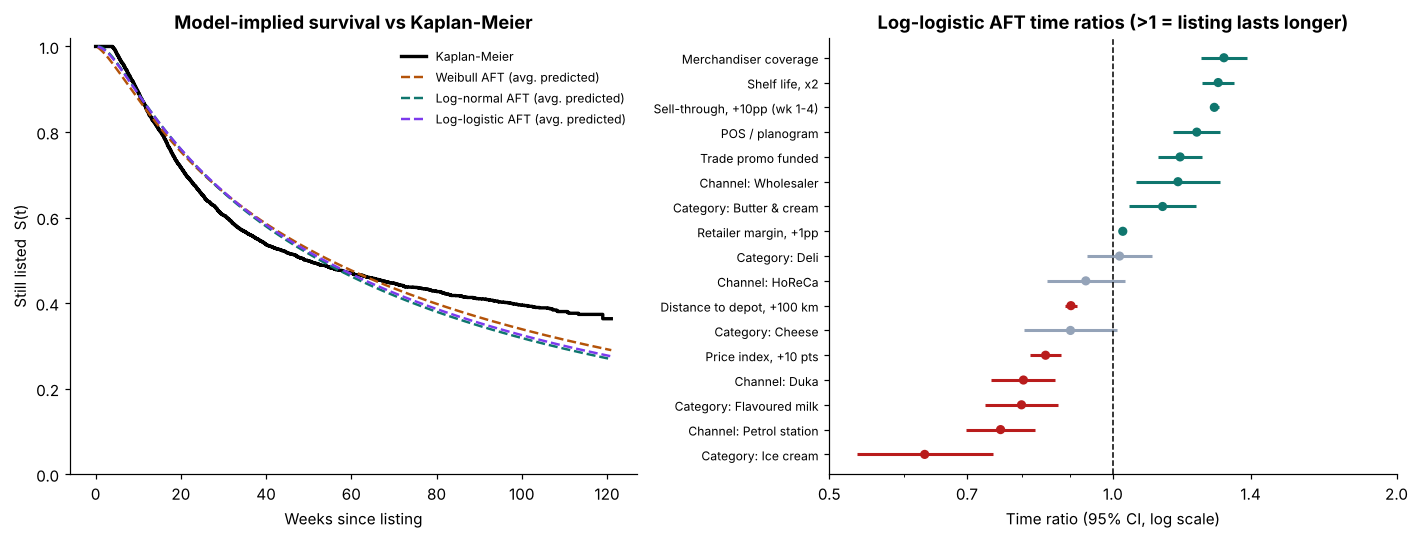

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
kmf.plot_survival_function(ax=ax[0], color="black", ci_show=False, lw=2.2, label="Kaplan-Meier")
grid = np.linspace(.5, 121, 240)
for (name, f), c in zip(aft.items(), [AMBER, TEAL, PURPLE]):
    ax[0].plot(grid, f.predict_survival_function(D, times=grid).mean(axis=1), color=c, lw=1.6, ls="--",
               label=f"{name} AFT (avg. predicted)")
ax[0].set(title="Model-implied survival vs Kaplan-Meier", xlabel="Weeks since listing", ylabel="Still listed  S(t)", ylim=(0, 1.02))
ax[0].legend(frameon=False, fontsize=8)

o = time_ratios(best_aft).sort_values("time_ratio")
c = np.where(o.p_value < .05, np.where(o.time_ratio > 1, TEAL, RED), GREY)
y = np.arange(len(o))
ax[1].hlines(y, o.ci_low, o.ci_high, color=c, lw=2); ax[1].scatter(o.time_ratio, y, color=c, s=25, zorder=3)
ax[1].axvline(1, color="black", ls="--", lw=1); ax[1].set_xscale("log")
ax[1].set_xticks([.5, .7, 1, 1.4, 2]); ax[1].get_xaxis().set_major_formatter(plt.ScalarFormatter()); ax[1].get_xaxis().set_minor_formatter(plt.NullFormatter())
ax[1].set_yticks(y, [LABELS.get(i, i) for i in o.index], fontsize=8)
ax[1].set(title=f"{best_aft} AFT time ratios (>1 = listing lasts longer)", xlabel="Time ratio (95% CI, log scale)")
fig.tight_layout(); fig.savefig(OUT / "08_parametric_aft.png", dpi=150); plt.show()

**Reading the chart:** all three parametric models track Kaplan-Meier well up to about week 60, then **under-predict long-term survival**: KM levels off at about 39% still listed at week 104, while the models predict about 30%. The data has a group of listings that become "permanent" range members, a **plateau** that standard AFT distributions can't capture. A **cure (mixture) model**, which estimates the share of listings that will never be delisted, would be the natural next step. For forecasts beyond a year the Cox model, which follows the data's own baseline, is safer.

## 10. How well do the models predict? Discrimination on held-out outlets

Inference (section 7) and prediction are different jobs. To measure prediction honestly we hold out **25% of outlets** (outlet number divisible by 4), so the test set contains outlets the models never saw. Splitting by outlet rather than by listing stops the model "recognising" an outlet from its other listings.

**Metrics:**

* **Harrell's concordance index (C-index):** take every comparable pair of listings (one was delisted before the other's observed time). C is the share of pairs where the model gave the earlier-delisted listing the higher risk. 0.5 = coin toss, 1.0 = perfect ranking. It is the survival version of ROC-AUC and handles censoring by only using pairs whose order is known.
* **Time-dependent AUC at week t (cumulative/dynamic, IPCW):** "among listings delisted by week *t* vs those still listed at *t*, how well does the predicted risk *by week t* separate them?". Censored listings are handled with **inverse probability of censoring weights** (Uno et al.), estimated from a KM curve of the censoring times in the training set.
* **IPCW Brier score at week t:** the mean squared error of the predicted probability of still being listed at *t*; lower is better. We compare against a "no-model" benchmark that gives everyone the overall KM estimate.

In [27]:
test = (df.outlet_id.str[1:].astype(int) % 4 == 0).values
Dtr, Dte = D[~test], D[test]
print(f"Train: {len(Dtr):,} listings ({df[~test].outlet_id.nunique():,} outlets, {Dtr.delisted.mean():.1%} delisted) | "
      f"Test: {len(Dte):,} listings ({df[test].outlet_id.nunique():,} outlets, {Dte.delisted.mean():.1%} delisted)")

models = {
    "Cox PH (all covariates)": CoxPHFitter().fit(Dtr, "weeks_listed", "delisted"),
    "Cox stratified by promo": CoxPHFitter().fit(Dtr, "weeks_listed", "delisted", strata=["trade_promo"]),
    f"{best_aft} AFT": type(aft[best_aft])().fit(Dtr, "weeks_listed", "delisted"),
    "Cox: sell-through only": CoxPHFitter().fit(Dtr[["sellthrough_per10pp", "weeks_listed", "delisted"]], "weeks_listed", "delisted"),
    "Cox: launch support + channel only": CoxPHFitter().fit(
        Dtr[["trade_promo", "pos_material", "has_merchandiser"] + [f"channel_{clean(c)}" for c in CHANNELS] + ["weeks_listed", "delisted"]],
        "weeks_listed", "delisted"),
}

cens = KaplanMeierFitter().fit(Dtr.weeks_listed, 1 - Dtr.delisted)
G = lambda t: np.clip(cens.survival_function_at_times(np.asarray(t) - 1e-6).values, .05, 1)

def td_auc(T, E, risk, t):
    cases, ctrl = (T <= t) & (E == 1), T > t
    w = 1 / G(T[cases]); rc, rk = risk[cases], np.sort(risk[ctrl])
    lo_, hi_ = np.searchsorted(rk, rc, "left"), np.searchsorted(rk, rc, "right")
    return np.sum(w * (lo_ + .5 * (hi_ - lo_))) / (w.sum() * ctrl.sum())

def ipcw_brier(T, E, S_t, t):
    died, alive = (T <= t) & (E == 1), T > t
    return np.mean(np.where(died, S_t ** 2 / G(T), 0) + np.where(alive, (1 - S_t) ** 2 / G([t])[0], 0))

T_te, E_te = Dte.weeks_listed.values, Dte.delisted.values
HORIZONS = [13, 26, 52]
km_null = KaplanMeierFitter().fit(Dtr.weeks_listed, Dtr.delisted)
res = []
for name, m in models.items():
    S_h = m.predict_survival_function(Dte, times=HORIZONS)[Dte.index].T.values  # n x len(HORIZONS); re-align columns (stratified models group them by stratum)
    if "AFT" in name:
        score = -m.predict_median(Dte).replace(np.inf, 1e6).values           # shorter predicted median = higher risk
    else:
        score = 1 - S_h[:, 1]                                                  # risk of delisting by week 26
    row = {"model": name, "C_index": concordance_index(T_te, -score, E_te)}
    for j, t in enumerate(HORIZONS):
        row[f"AUC_wk{t}"] = td_auc(T_te, E_te, 1 - S_h[:, j], t)
        row[f"Brier_wk{t}"] = ipcw_brier(T_te, E_te, S_h[:, j], t)
    res.append(row)
null = {"model": "No model (overall KM)", "C_index": .5}
for t in HORIZONS:
    null[f"AUC_wk{t}"] = .5; null[f"Brier_wk{t}"] = ipcw_brier(T_te, E_te, np.full(len(T_te), km_null.predict(t)), t)
res.append(null)
metrics = pd.DataFrame(res).set_index("model")
metrics.to_csv(OUT / "model_metrics.csv")
metrics.round(3)

Train: 5,161 listings (1,666 outlets, 52.3% delisted) | Test: 1,763 listings (562 outlets, 52.3% delisted)


,C_index,AUC_wk13,Brier_wk13,AUC_wk26,Brier_wk26,AUC_wk52,Brier_wk52
model,,,,,,,
Cox PH (all covariates),0.811,0.881,0.089,0.866,0.135,0.874,0.145
Cox stratified by promo,0.811,0.886,0.086,0.866,0.135,0.877,0.144
Log-logistic AFT,0.811,0.881,0.089,0.867,0.137,0.875,0.145
Cox: sell-through only,0.782,0.855,0.101,0.835,0.151,0.850,0.158
Cox: launch support + channel only,0.674,0.745,0.121,0.713,0.198,0.708,0.220
No model (overall KM),0.500,0.500,0.135,0.500,0.228,0.500,0.253


**Interpretation:**

* The full **Cox** model, the **stratified Cox** model and the **log-logistic AFT** all reach a test **C-index of 0.81**, essentially the same as in-sample (0.81), so there is **no sign of overfitting**.
* **Sell-through alone gets 0.78**. One number available at week 4 carries most of the predictive signal, which is very good news for a simple early-warning rule.
* **Launch support + channel alone reach only 0.67.** The things known *before* launch predict much less than the first month's sales.
* **Time-dependent AUC** is about **0.87-0.89** at 13, 26 and 52 weeks for the full models, and the **IPCW Brier scores** (0.086-0.089 at week 13, 0.135 at week 26, about 0.145 at week 52) are well below the no-model benchmark (0.135, 0.228, 0.253). The stratified model is marginally best at weeks 13 and 52, because it captures the promo timing.

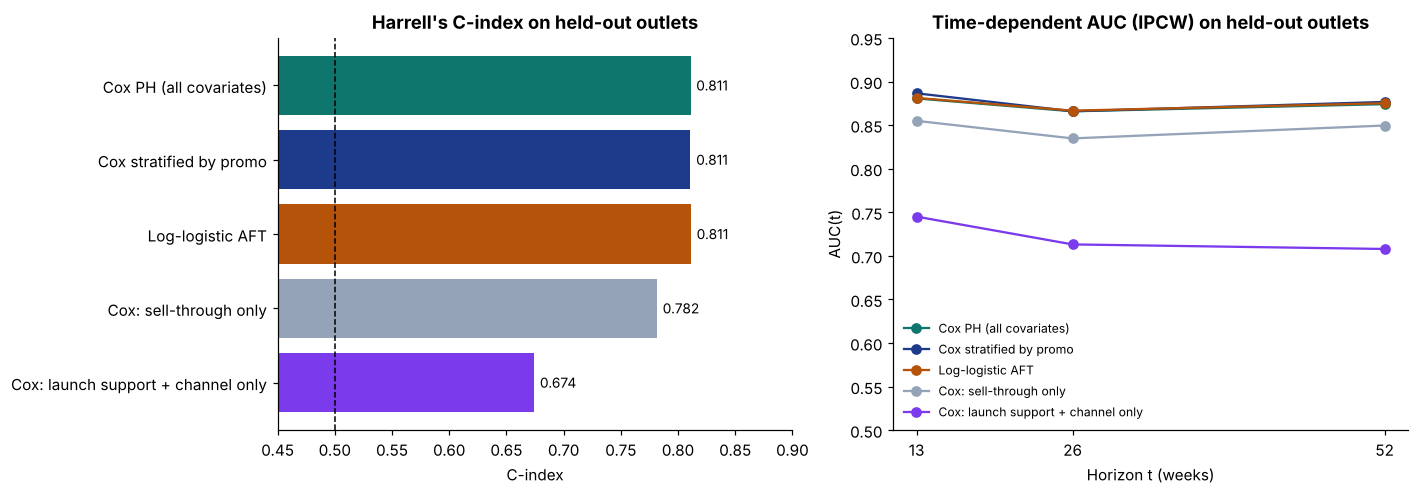

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
mm = metrics.drop("No model (overall KM)")
cols_ = [TEAL, NAVY, AMBER, GREY, PURPLE]
ax[0].barh(mm.index[::-1], mm.C_index[::-1], color=cols_[::-1])
for i, v in enumerate(mm.C_index[::-1]): ax[0].text(v + .005, i, f"{v:.3f}", va="center", fontsize=9)
ax[0].axvline(.5, color="black", ls="--", lw=1); ax[0].set(xlim=(.45, .9), title="Harrell's C-index on held-out outlets", xlabel="C-index")
for (name, r_), c in zip(mm.iterrows(), cols_):
    ax[1].plot(HORIZONS, [r_[f"AUC_wk{t}"] for t in HORIZONS], "o-", color=c, label=name)
ax[1].set(xticks=HORIZONS, title="Time-dependent AUC (IPCW) on held-out outlets", xlabel="Horizon t (weeks)", ylabel="AUC(t)", ylim=(.5, .95))
ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "09_discrimination.png", dpi=150); plt.show()

Discrimination is stable across horizons: the models rank listings as well for one-year risk as for first-quarter risk.

## 11. Restricted mean survival time (RMST): effects in *weeks*, not ratios

Hazard ratios are hard to explain to a sales director, and a median doesn't exist for groups where fewer than half the listings are delisted. The **restricted mean survival time** up to a horizon τ is the **area under the survival curve** from 0 to τ:

$$\text{RMST}(\tau) = \int_0^{\tau} S(t)\,dt$$

It is the **expected number of weeks on shelf during the first τ weeks**. With τ = 52, RMST answers *"of the first year after listing, how many weeks does a listing spend on the shelf, on average?"*. The difference between two groups is the **listing-weeks gained per listing**. RMST doesn't need proportional hazards, so it is valid even for the promo comparison with its crossing hazards.

Differences below are **unadjusted** (straight from KM curves). Section 13 uses the Cox model to give **adjusted** gains.

In [29]:
def rmst(d, tau=TAU):
    # KM-based RMST up to tau and the variance of the ESTIMATE (Greenwood-type formula, as in R's survRM2 / print.survfit).
    # Note: lifelines' return_variance gives the variance of the restricted survival TIME, not of its mean, so we compute it here.
    k = KaplanMeierFitter().fit(d.weeks_listed, d.delisted)
    m = restricted_mean_survival_time(k, t=tau)
    ev = k.event_table[(k.event_table.observed > 0) & (k.event_table.index <= tau)]
    tj = ev.index.values; Sj = k.survival_function_at_times(tj).values
    A = np.cumsum((Sj * np.diff(np.append(tj, tau)))[::-1])[::-1]            # area under S from t_j to tau
    n_, d_ = ev.at_risk.values.astype(float), ev.observed.values.astype(float)
    v = np.sum(np.where(n_ > d_, A ** 2 * d_ / (n_ * (n_ - d_) + 1e-12), 0))
    assert abs((tj[0] + A[0]) - m) < 1e-6 if tj[0] > 0 else True
    return m, v

rm_rows = []
for colname, a_lbl, b_lbl in [("trade_promo", 1, 0), ("pos_material", 1, 0), ("has_merchandiser", 1, 0)]:
    (ma, va), (mb, vb) = rmst(df[df[colname] == a_lbl]), rmst(df[df[colname] == b_lbl])
    se = np.sqrt(va + vb)
    rm_rows.append({"comparison": f"{colname} yes vs no", "rmst_a": ma, "rmst_b": mb, "difference_wks": ma - mb,
                    "ci_low": ma - mb - 1.96 * se, "ci_high": ma - mb + 1.96 * se})
(ma, va), (mb, vb) = rmst(df[df.sellthrough_band == "≥70%"]), rmst(df[df.sellthrough_band == "<30%"])
se = np.sqrt(va + vb)
rm_rows.append({"comparison": "sell-through ≥70% vs <30%", "rmst_a": ma, "rmst_b": mb, "difference_wks": ma - mb,
                "ci_low": ma - mb - 1.96 * se, "ci_high": ma - mb + 1.96 * se})
rmst_cmp = pd.DataFrame(rm_rows)
rmst_cmp.to_csv(OUT / "rmst_comparisons.csv", index=False)
print(f"Overall RMST({TAU}) = {rmst(df)[0]:.1f} weeks out of {TAU}")
rmst_cmp.round(2)

Overall RMST(52) = 36.1 weeks out of 52


,comparison,rmst_a,rmst_b,difference_wks,ci_low,ci_high
0,trade_promo yes vs no,40.76,32.96,7.80,6.98,8.62
1,pos_material yes vs no,40.90,32.11,8.80,7.97,9.62
2,has_merchandiser yes vs no,41.64,31.86,9.78,8.97,10.60
3,sell-through ≥70% vs <30%,47.37,18.63,28.74,27.94,29.54


**Interpretation:** an average new listing spends **36.1 of its first 52 weeks** on the shelf. Unadjusted, in the first year:

* **Trade promotion** is associated with **+7.8 listing-weeks** (95% CI 7.0-8.6)
* **POS material** with **+8.8 weeks** (8.0-9.6)
* a **merchandiser** with **+9.8 weeks** (9.0-10.6)
* **≥ 70% early sell-through vs < 30%: +28.7 weeks** (47.4 vs 18.6)

These raw gaps still include channel mix (supermarkets get more support), so they **overstate** the causal value of support. Section 13 gives the adjusted figures. The R script reproduces the promo RMSTs exactly (40.76 vs 32.96 weeks).

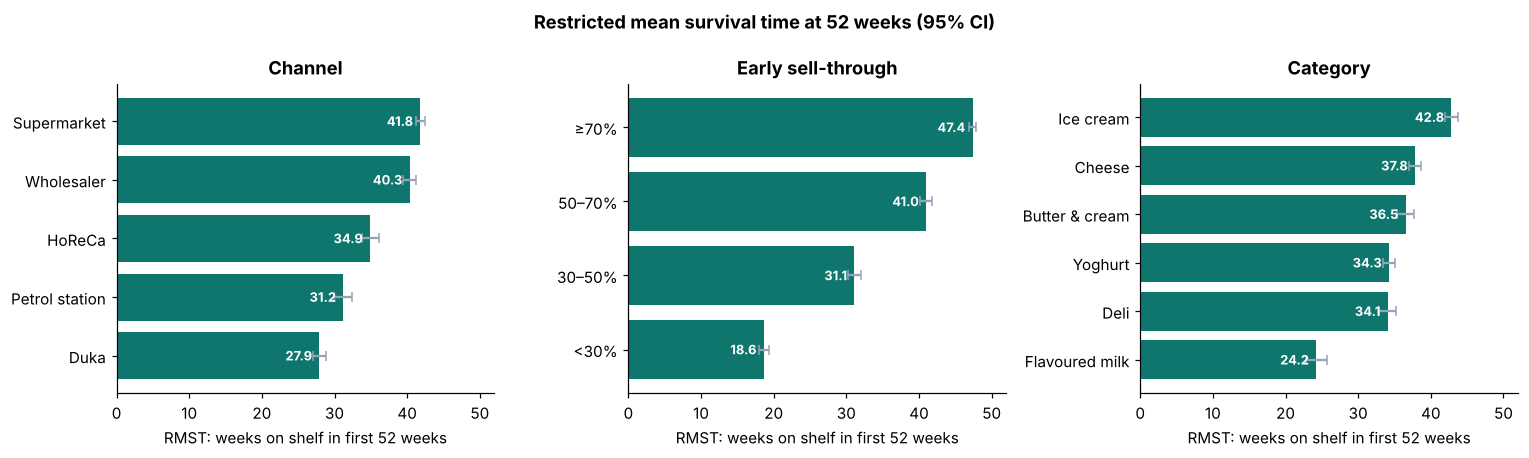

variable,category,channel,sellthrough_band
group,,,
30–50%,NaN,NaN,31.1
50–70%,NaN,NaN,41.0
<30%,NaN,NaN,18.6
Butter & cream,36.5,NaN,NaN
Cheese,37.8,NaN,NaN
Deli,34.1,NaN,NaN
Duka,NaN,27.9,NaN
Flavoured milk,24.2,NaN,NaN
HoReCa,NaN,34.9,NaN


In [30]:
grp = []
for colname in ["channel", "sellthrough_band", "category"]:
    for g, d in df.groupby(colname, observed=True):
        m, v = rmst(d); grp.append({"variable": colname, "group": str(g), "rmst_52": m, "se": np.sqrt(v)})
grp = pd.DataFrame(grp)
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for a, (colname, title) in zip(ax, [("channel", "Channel"), ("sellthrough_band", "Early sell-through"), ("category", "Category")]):
    g = grp[grp.variable == colname]
    if colname != "sellthrough_band": g = g.sort_values("rmst_52")
    a.barh(g.group, g.rmst_52, xerr=1.96 * g.se, color=TEAL, ecolor=GREY, capsize=3)
    for i, v in enumerate(g.rmst_52): a.text(v - 1, i, f"{v:.1f}", va="center", ha="right", color="white", fontsize=8.5, fontweight="bold")
    a.set(title=title, xlabel=f"RMST: weeks on shelf in first {TAU} weeks", xlim=(0, TAU))
fig.suptitle(f"Restricted mean survival time at {TAU} weeks (95% CI)", fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "10_rmst.png", dpi=150); plt.show()
grp.pivot_table(index="group", columns="variable", values="rmst_52").round(1)

**Interpretation:** in the first year after listing, a new SKU in a **supermarket** is on the shelf for about **42 weeks** on average, against **28 in a duka**. Low-selling listings (< 30% sell-through) last only **19 weeks**. By category, **flavoured milk** is weakest (24 weeks) and **ice cream** strongest (43 weeks, thanks to its long shelf life).

## 12. Predicted survival curves for example listings

The stratified Cox model (section 8) turns any combination of outlet, product and launch conditions into a full survival curve. Four illustrative profiles, all listed at category price parity with an 18-20% margin:

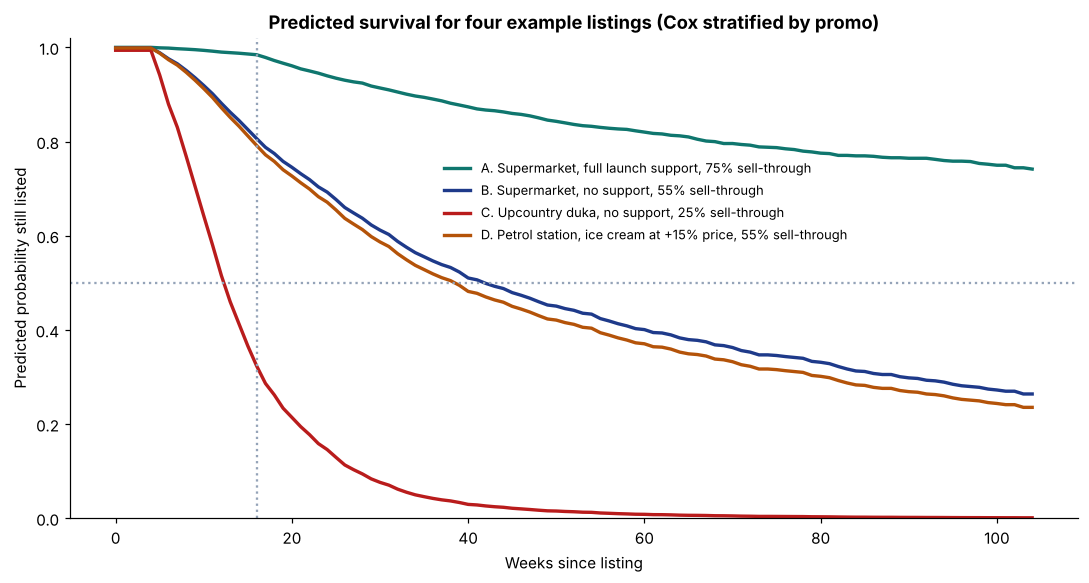

,P(listed) wk 13,P(listed) wk 26,P(listed) wk 52,RMST_52 (wks)
"A. Supermarket, full launch support, 75% sell-through",0.99,0.93,0.84,48.37
"B. Supermarket, no support, 55% sell-through",0.86,0.66,0.44,36.09
"C. Upcountry duka, no support, 25% sell-through",0.46,0.11,0.01,14.86
"D. Petrol station, ice cream at +15% price, 55% sell-through",0.85,0.64,0.41,35.10


In [31]:
base = dict(sellthrough_per10pp=5.5, trade_promo=0, pos_material=0, has_merchandiser=0, price_index_per10=0.0,
            retailer_margin_pp=18.0, distance_per100km=0.3, log2_shelf_life=np.log2(28),
            **{f"channel_{clean(c)}": 0 for c in CHANNELS}, **{f"category_{clean(c)}": 0 for c in CATEGORIES})
profiles = pd.DataFrame([
    {**base, "trade_promo": 1, "pos_material": 1, "has_merchandiser": 1, "sellthrough_per10pp": 7.5, "retailer_margin_pp": 20,
     "_name": "A. Supermarket, full launch support, 75% sell-through"},
    {**base, "_name": "B. Supermarket, no support, 55% sell-through"},
    {**base, "channel_Duka": 1, "sellthrough_per10pp": 2.5, "distance_per100km": 2.5,
     "_name": "C. Upcountry duka, no support, 25% sell-through"},
    {**base, "channel_Petrol_station": 1, "category_Ice_cream": 1, "log2_shelf_life": np.log2(365), "price_index_per10": 1.5,
     "_name": "D. Petrol station, ice cream at +15% price, 55% sell-through"},
]).set_index("_name")
grid = np.arange(0, 105)
S_prof = cph_s.predict_survival_function(profiles, times=grid)[profiles.index]   # re-align: stratified predictions come back grouped by stratum

fig, ax = plt.subplots(figsize=(10, 5.4))
for (name, sp), c in zip(S_prof.items(), [TEAL, NAVY, RED, AMBER]):
    ax.plot(grid, sp, color=c, lw=2.2, label=name)
ax.axhline(.5, color=GREY, ls=":"); ax.axvline(PROMO_WEEKS, color=GREY, ls=":")
ax.set(ylim=(0, 1.02), xlabel="Weeks since listing", ylabel="Predicted probability still listed",
       title="Predicted survival for four example listings (Cox stratified by promo)")
ax.legend(frameon=False, fontsize=8.5, loc="center left", bbox_to_anchor=(.36, .66))
fig.tight_layout(); fig.savefig(OUT / "11_predicted_profiles.png", dpi=150); plt.show()

prof_tab = pd.DataFrame({"P(listed) wk 13": S_prof.loc[13], "P(listed) wk 26": S_prof.loc[26], "P(listed) wk 52": S_prof.loc[52],
                         "RMST_52 (wks)": [np.trapezoid(S_prof.loc[:TAU, c], grid[:TAU + 1]) for c in S_prof]})
prof_tab.round(2)

**Interpretation:**

* **A: Supermarket with full launch support and strong sell-through:** 84% chance of still being listed after a year, about **48 of 52 weeks** on shelf.
* **B: The same supermarket with no support and average sell-through:** 44% after a year, **36 weeks**. Its curve drops steadily through the first quarters.
* **C: Upcountry duka, no support, weak sell-through:** 46% after one quarter, **essentially zero after a year**, about **15 weeks** on shelf. Unless something changes, this listing is lost within months.
* **D: Petrol-station ice cream priced 15% above the category:** close to B (**35 weeks**). The channel and price penalties are roughly cancelled out by ice cream's long shelf life.

Curves like these turn the model into a planning tool: before committing launch money to an outlet type, the commercial team can see the expected listing life it is buying.

## 13. Business translation: what is launch support worth?

### Two different questions, two different models

Trade promotion and POS material work partly **by raising early sell-through**. Sell-through is therefore a **mediator** of launch support, not a confounder. That has a consequence a biostatistician learns early:

* The model in section 7 **adjusts for sell-through**, so its promo / POS / merchandiser effects are **direct effects**: the protection *beyond* what flows through better early sales.
* To value a launch investment we need the **total effect**, so we refit the Cox model **without** sell-through (still stratified by promo because of the non-proportional hazards).

### Method: g-computation (standardisation)

For every one of the 6,924 listings we predict the survival curve twice: once *with* the support and once *without*, keeping everything else as it actually was. The average difference in RMST(52) is the expected number of **listing-weeks gained in the first year** per supported listing, adjusted for channel, category, price, margin, distance and shelf life.

### Assumptions for the money (illustrative, clearly not real company figures)

| Channel | Gross margin to us per listing-week (KES) | Launch promo cost per listing (KES) |
|---|---:|---:|
| Supermarket | 3,500 | 9,000 |
| Wholesaler | 5,000 | 7,000 |
| Duka | 450 | 1,200 |
| HoReCa | 1,400 | 2,500 |
| Petrol station | 900 | 2,000 |

In [32]:
Dt = design(df, sellthrough=False).assign(weeks_listed=df.weeks_listed, delisted=df.delisted)
cph_total = CoxPHFitter().fit(Dt, "weeks_listed", "delisted", strata=["trade_promo"])
total_hr = cph_total.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
total_hr.columns = ["HR_total_effect", "ci_low", "ci_high", "p_value"]
cmp_direct = total_hr.join(hr[["hazard_ratio"]].rename(columns={"hazard_ratio": "HR_direct (adj. sell-through)"}))
cmp_direct.loc[["pos_material", "has_merchandiser", "price_index_per10"]].round(3)

,HR_total_effect,ci_low,ci_high,p_value,HR_direct (adj. sell-through)
covariate,,,,,
pos_material,0.607,0.562,0.656,0.0,0.726
has_merchandiser,0.604,0.559,0.652,0.0,0.669
price_index_per10,1.778,1.693,1.867,0.0,1.327


**Interpretation:** once we stop adjusting for the mediator, the **total effects are larger**: POS HR **0.61** (vs 0.73 direct) and merchandiser **0.60** (vs 0.67). Part of their benefit works *through* better early sales. The biggest change is for **price**: per +10 index points the total HR is **1.78** vs 1.33 direct. Most of the damage from premium pricing comes from **slower early sales**. Adjusting for sell-through would understate the true cost of overpricing a launch.

In [33]:
grid52 = np.arange(0, TAU + 1)
def rmst_pred(X):
    S_ = cph_total.predict_survival_function(X, times=grid52)[X.index].values   # keep row order (stratified model)
    return np.trapezoid(S_, grid52, axis=0)

Xb = Dt.drop(columns=["weeks_listed", "delisted"])
gains = pd.DataFrame(index=df.index)
for lever in ["trade_promo", "pos_material", "has_merchandiser"]:
    gains[lever] = rmst_pred(Xb.assign(**{lever: 1})) - rmst_pred(Xb.assign(**{lever: 0}))
gains["channel"] = df.channel

MARGIN_WK = {"Supermarket": 3500, "Wholesaler": 5000, "Duka": 450, "HoReCa": 1400, "Petrol station": 900}
PROMO_COST = {"Supermarket": 9000, "Wholesaler": 7000, "Duka": 1200, "HoReCa": 2500, "Petrol station": 2000}
val = gains.groupby("channel").mean()
val.columns = [f"wks_gained_{c}" for c in val.columns]
val["margin_per_wk"] = val.index.map(MARGIN_WK)
val["promo_cost"] = val.index.map(PROMO_COST)
val["promo_margin_gained"] = val.wks_gained_trade_promo * val.margin_per_wk
val["promo_ROI"] = val.promo_margin_gained / val.promo_cost
val["pos_margin_gained"] = val.wks_gained_pos_material * val.margin_per_wk
val["merch_margin_gained"] = val.wks_gained_has_merchandiser * val.margin_per_wk
val = val.loc[["Supermarket", "Wholesaler", "HoReCa", "Petrol station", "Duka"]]
val.to_csv(OUT / "launch_support_value.csv")
print("Average listing-weeks gained in the first 52 weeks (all listings):",
      {k: round(v, 2) for k, v in gains[["trade_promo", "pos_material", "has_merchandiser"]].mean().items()})
val.round(2)

Average listing-weeks gained in the first 52 weeks (all listings): {'trade_promo': 5.28, 'pos_material': 4.78, 'has_merchandiser': 4.82}


,wks_gained_trade_promo,wks_gained_pos_material,wks_gained_has_merchandiser,margin_per_wk,promo_cost,promo_margin_gained,promo_ROI,pos_margin_gained,merch_margin_gained
channel,,,,,,,,,
Supermarket,4.15,4.07,4.03,3500,9000,14534.16,1.61,14228.93,14098.42
Wholesaler,4.41,4.05,4.17,5000,7000,22073.45,3.15,20227.93,20871.70
HoReCa,5.60,5.06,5.18,1400,2500,7836.80,3.13,7084.65,7247.06
Petrol station,6.39,5.61,5.65,900,2000,5749.62,2.87,5049.02,5083.16
Duka,6.76,5.75,5.80,450,1200,3040.86,2.53,2587.88,2607.95


**Interpretation (adjusted total effects, first 52 weeks):**

* Averaged over all listings, **trade promotion adds about 5.3 listing-weeks**, **POS about 4.8** and **a merchandiser about 4.8** in the first year.
* The gain in **weeks** is largest where baseline risk is highest: promo adds **6.8 weeks in dukas** and **6.4 in petrol stations**, but only **4.2 in supermarkets**, where listings survive well anyway.
* In **money**, the picture flips because a supermarket or wholesaler listing earns far more per week. Under the stated assumptions, promo funding returns **KES 3.2 of first-year margin per shilling in wholesalers**, **3.1 in HoReCa**, **2.9 in petrol stations**, **2.5 in dukas** and **1.6 in supermarkets**. Supermarkets have the **lowest return** because their listings would mostly have survived without it and their promo fees are highest.
* POS material is worth roughly KES 14k (supermarket) to 20k (wholesaler) of first-year margin per listing, and KES 2.6k in a duka. Any POS programme costing less than this pays back.

**Caveats:** costs and margins are illustrative assumptions, not company figures. The horizon is one year, and after week 16 promo-funded listings carry a slightly higher hazard, so gains measured over longer horizons would be a little smaller. Promotional *sales uplift* during the promo isn't counted, so these are listing-survival gains only.

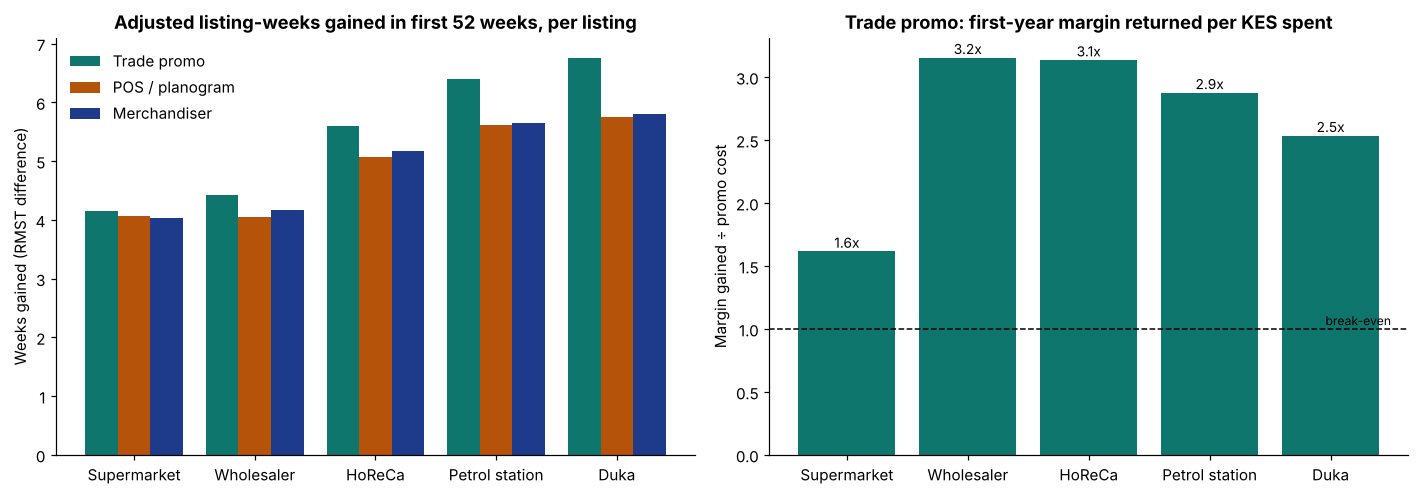

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(len(val)); w = .27
for j, (c_, colr, lab) in enumerate([("wks_gained_trade_promo", TEAL, "Trade promo"), ("wks_gained_pos_material", AMBER, "POS / planogram"),
                                     ("wks_gained_has_merchandiser", NAVY, "Merchandiser")]):
    ax[0].bar(x + (j - 1) * w, val[c_], w, color=colr, label=lab)
ax[0].set_xticks(x, val.index); ax[0].legend(frameon=False)
ax[0].set(title=f"Adjusted listing-weeks gained in first {TAU} weeks, per listing", ylabel="Weeks gained (RMST difference)")
bars = ax[1].bar(x, val.promo_ROI, color=np.where(val.promo_ROI >= 1, TEAL, RED))
ax[1].axhline(1, color="black", ls="--", lw=1); ax[1].text(len(val) - .5, 1.03, "break-even", ha="right", fontsize=8)
for xi, v in zip(x, val.promo_ROI): ax[1].text(xi, v + .03, f"{v:.1f}x", ha="center", fontsize=9)
ax[1].set_xticks(x, val.index)
ax[1].set(title="Trade promo: first-year margin returned per KES spent", ylabel="Margin gained ÷ promo cost")
fig.tight_layout(); fig.savefig(OUT / "12_launch_support_value.png", dpi=150); plt.show()

On these assumptions promo funding pays back in every channel, with the highest return in wholesalers, HoReCa and petrol stations. Before any budget moves, test it with a **randomised launch-support trial**: randomise promo funding across comparable outlets for the next launch.

### Week-4 early warning: which listings to rescue first

Early sell-through is known at week 4, before any delisting can happen. That makes it the natural trigger for a **week-4 listing review**. Using the full stratified Cox model, we also score every listing that is **still on the shelf at the cut-off** with its probability of being delisted in the **next 13 weeks**, given how long it has already survived (a *conditional* survival probability, $1 - S(t+13)/S(t)$).

In [35]:
wk4 = df.groupby("sellthrough_band", observed=True).agg(listings=("listing_id", "size")).assign(share=lambda d: d.listings / len(df))
wk4["P(delisted by wk 26)"] = [1 - KaplanMeierFitter().fit(d.weeks_listed, d.delisted).predict(26) for _, d in df.groupby("sellthrough_band", observed=True)]
wk4["RMST_52"] = [rmst(d)[0] for _, d in df.groupby("sellthrough_band", observed=True)]
display(wk4.round(3))

live = df[df.status == "Censored: still listed at cut-off"].copy()
Xl = D.loc[live.index].drop(columns=["weeks_listed", "delisted"])
grid_all = np.arange(0, 136)
H = cph_s.predict_cumulative_hazard(Xl, times=grid_all)[Xl.index].values   # times x listings, in listing order
age = live.weeks_listed.values
H_now = np.array([np.interp(a, grid_all, H[:, i]) for i, a in enumerate(age)])
H_13 = np.array([np.interp(a + 13, grid_all, H[:, i]) for i, a in enumerate(age)])
live["p_delist_next_13wks"] = 1 - np.exp(-(H_13 - H_now))
live["risk_band"] = pd.cut(live.p_delist_next_13wks, [0, .1, .25, .5, 1], labels=["<10%", "10–25%", "25–50%", ">50%"], include_lowest=True)
cols_out = ["listing_id", "sku_name", "outlet_id", "channel", "region", "weeks_listed", "sellthrough_4wk_pct", "trade_promo",
            "pos_material", "has_merchandiser", "price_index", "p_delist_next_13wks", "risk_band"]
live.sort_values("p_delist_next_13wks", ascending=False)[cols_out].round(3).to_csv(OUT / "live_listing_risk_scores.csv", index=False)
print(f"{len(live):,} listings still on shelf at cut-off; expected delistings in next 13 weeks: {live.p_delist_next_13wks.sum():.0f}")
display(live.groupby("risk_band", observed=True).agg(listings=("listing_id", "size"), mean_age_wks=("weeks_listed", "mean"),
                                                  mean_sellthrough=("sellthrough_4wk_pct", "mean"),
                                                  expected_delistings=("p_delist_next_13wks", "sum")).round(1))
live.sort_values("p_delist_next_13wks", ascending=False)[cols_out].head(8).round(3)

,listings,share,P(delisted by wk 26),RMST_52
sellthrough_band,,,,
<30%,1612,0.233,0.790,18.631
30–50%,1394,0.201,0.465,31.102
50–70%,1486,0.215,0.236,40.986
≥70%,2432,0.351,0.094,47.373


3,109 listings still on shelf at cut-off; expected delistings in next 13 weeks: 248


,listings,mean_age_wks,mean_sellthrough,expected_delistings
risk_band,,,,
<10%,2398,71.7,78.1,85.9
10–25%,508,50.4,52.2,79.0
25–50%,153,34.7,34.3,52.2
>50%,50,23.5,19.7,31.1


,listing_id,sku_name,outlet_id,channel,region,weeks_listed,sellthrough_4wk_pct,trade_promo,pos_material,has_merchandiser,price_index,p_delist_next_13wks,risk_band
6720,L06721,Mozzarella 500g (food service),O02207,Petrol station,Coast,18.43,25.0,1,0,0,106.6,0.880,>50%
6796,L06797,Mozzarella 500g (food service),O02174,Duka,Rift Valley,17.14,15.2,1,0,0,109.2,0.860,>50%
6859,L06860,Mozzarella 500g (food service),O00368,Duka,Nairobi,15.14,6.0,0,1,0,105.8,0.769,>50%
6853,L06854,Mozzarella 500g (food service),O00350,Duka,Nairobi,15.29,13.8,0,0,0,108.9,0.758,>50%
6700,L06701,Mozzarella 500g (food service),O00005,Duka,Nairobi,18.57,15.2,1,0,0,102.0,0.746,>50%
6541,L06542,Fresh cream 250ml,O01038,HoReCa,Coast,24.43,19.6,0,0,0,91.4,0.743,>50%
6316,L06317,Fresh cream 250ml,O00734,Duka,Nairobi,29.29,8.7,0,1,1,109.3,0.735,>50%
5948,L05949,Fresh cream 250ml,O01365,Duka,Nairobi,35.71,15.4,0,1,0,106.3,0.735,>50%


**Interpretation:**

* **The week-4 sell-through band is a near-perfect triage rule.** The **23% of listings below 30% sell-through** have a **79%** chance of being delisted by week 26 and last only 19 weeks of the first year. Listings above 70% have just a **9%** chance. A week-4 review that sends merchandisers, re-merchandising or a targeted consumer promo to the < 30% (and 30-50%) bands puts effort where listings can still be saved.
* Of the **3,109 listings still on shelf** at the cut-off, the model expects about **248** to be delisted in the next 13 weeks. The **50 listings above 50% risk** are young (about 24 weeks old) with weak sell-through (mean 20%), mostly recent launches (mozzarella, fresh cream) in dukas, petrol stations and HoReCa. A further **153** are at 25-50% risk. These 203 listings make up the field team's rescue list in `live_listing_risk_scores.csv`; the 2,398 low-risk listings (mean age 72 weeks) need no attention.
* Risk depends on **age**. A listing that has survived a year has passed the danger zone, so conditional survival matters more than the original launch forecast.

---

## 14. Recommended actions

| Finding | Action | Owner |
|---|---|---|
| Half of new listings are gone within ~50 weeks; risk peaks in the first two quarters | Track every launch with a **listing survival curve**, not a "% listed" snapshot. Review launches at weeks 13, 26 and 52 against the benchmark curve | Category management + Analytics |
| Week-4 sell-through is the strongest single predictor (C = 0.78 alone) | Introduce a **week-4 listing review**: listings < 30% sell-through get a rescue plan (merchandiser visit, shelf/planogram fix, price check, sampling) | Trade marketing + Field sales |
| Trade promo protects strongly while it runs (HR 0.32) but not afterwards (HR 1.17) | Design promos as a **bridge to sell-through**: set week-12 sell-through targets, plan the **post-promo handover** (POS, merchandising) before funding ends, and avoid hard stops right before range reviews | Trade marketing |
| Merchandisers and POS each add about 5 listing-weeks in year 1 | Prioritise merchandiser routes and POS for **new launches** in wholesalers and HoReCa, where weeks gained × margin is highest | Sales operations |
| Premium pricing hurts mainly through slower early sales (total HR 1.78 per +10 pts) | Launch at or near **category price parity**; take price later, once the listing is established | Pricing / Revenue management |
| Retailer margin helps (≈4% lower hazard per point) | Model margin trade-offs explicitly in listing negotiations | Key account management |
| Remote outlets delist faster (+16% hazard per 100 km) | Check delivery reliability for new SKUs upcountry, or route them through wholesalers | Supply chain |
| ~200 live listings at > 25% risk of delisting in the next quarter | Work the **ranked rescue list** (`live_listing_risk_scores.csv`) every month | Field sales |

## 15. Where survival analysis is used in business

| Domain | "Event" | Typical question |
|---|---|---|
| **FMCG / retail (this project)** | SKU delisted, outlet stops ordering, promo-driven listing lost | How long do listings last, what keeps them on shelf? |
| **Customer analytics** | Churn / cancellation | *When* will a customer leave, not just *whether* (handles customers who haven't left *yet*) |
| **Telecoms & mobile money** | Subscriber churn, wallet dormancy | Time-to-churn by tariff and usage, retention-offer timing |
| **Banking & micro-finance** | Loan default, prepayment, account closure | Credit risk over the loan's life (IFRS 9 lifetime PD) |
| **Insurance** | Policy lapse, claim | Lapse curves for pricing and reserving |
| **HR / people analytics** | Employee resignation | Time-to-attrition drivers, hiring cohorts |
| **Manufacturing & engineering** | Machine / component failure | Reliability (Weibull analysis), maintenance scheduling, warranty costs |
| **SaaS & subscriptions** | Cancellation, time-to-upgrade | Lifetime value from RMST, onboarding effectiveness |
| **Healthcare & public health** | Death, relapse, loss to follow-up | Clinical trials, TB / HIV treatment retention: the field these methods came from |
| **Marketing** | Time to first / repeat purchase | Repeat-purchase curves for new products, campaign timing |

## 16. Limitations and next steps

* **Synthetic data.** The effect sizes are illustrative. Real listing data would need careful definition of a "delisting" (no orders for X weeks? a formal range-review decision?) and of the listing date.
* **Observational, not experimental.** Promo funding, POS and merchandisers are not randomly assigned, and adjusting for observed confounders can't rule out unobserved ones (for example, sales reps directing support to outlets they already know will perform). A **randomised launch-support trial** would give causal estimates.
* **Mediation.** Sell-through is a mediator of launch support. We report both direct (adjusted) and total (unadjusted for sell-through) effects; a formal mediation analysis would split them properly.
* **Clustering.** Listings are clustered within SKUs (15 launches) and outlets. SKU-level effects (category, shelf life) are imprecise; robust standard errors are reported. A **shared-frailty Cox model** (`coxph(... + frailty(sku_id))` in R) would be the natural extension.
* **Competing risks.** Outlet closure is handled as censoring, which estimates the *cause-specific* delisting hazard. For "what share of listings will be lost to delisting vs closure" a **Fine-Gray** or Aalen-Johansen cumulative incidence analysis would be the right tool. With 2.8% closures the difference is small here.
* **Long-term plateau.** The parametric models under-predict long-run survival; a **cure (mixture) model** would estimate the share of listings that become permanent.
* **Time-varying covariates.** Sell-through, pricing and stock-outs change after week 4. Feeding weekly data into a **counting-process Cox model** (the same machinery as the time-split model) would allow a dynamic early-warning score that updates every week.
* **Machine-learning extensions.** Random survival forests or gradient-boosted survival models could capture interactions (for example ice cream × petrol station). With a C-index of 0.81 from an interpretable model, the bar for a black box to justify itself is high.